Özellik Mühendisliği eğitimine hoş geldiniz!


Eğitimi tamamladığınız zaman aşağıdaki konular hakkında bilgi sahibi olacaksınız:
Outliers
Missing Values
Encoding Scaling
Feature Extraction

# 1 ) OUTLİERS

# OUTLİERS

FEATURE ENGINEERING & DATA PRE-PROCESSING

Veriden değer çıartmak lazım, bu bölümde : outliers(aykırı değerler), missing values(eksik değerler), encodig işlemleri, feature scaling(özellik ölçeklendirme), feature extraction(özellik çıkarımı), feature ıntreactions(özellik etkileşimleri), end to end application(uçtan uca uygulama)

uygulamalı makine öğrenmesi temelinde değişken mühendisliğidir. Andrew  Ng, yapay zekanın önde gelen isimlerinden.

değişken müh iyi anlamak önemlidir makine öğrenmesi için önemlidir.

ÖZellik mühendisliği:
Özelliklerin üzerinden gerçekleştirilen çalışmalar.Ham veriden değişken üretmek demektir.

Veri önişleme verinin uygun hale getirilmesi sürecidir. özellik müh. veri önişlemenin alt başlıklarından biridir. büyük çerçeve burada veri önişlemedir aslında verinin hazırlığıdır.

# Aykırı Değerler (outliers)

Verideki genel eğilimin oldukça dışına çıkan değerlere aykırı değer denir. Peki aykırı değer neye sebep olur onu inceleyeceğiz. elimizdeki veri setinde doğrusal olarak incelendiğinde negatif bir veri varken 3 aykırı değer eklendiğinde iliişki pozitif ilişkiye dönmektedir. yönü ve şiddeti değişmiştir. yani aykırı değerler ilişkinin yönünü ve şiddetini değiştirebilirler. Aykırı değerler neye göre belirlenir? 1- sektöre bilgisi, 2-standart sapma yaklaşımı, 3-Z-skor yaklaşımı, 4- boxplot yöntemi(interquartile range, iqr) yöntemleri mevcuttur. bunlar tek değişkenlidir. çok değişkenli olarak ise LOF ymntemini değerlendiriyor olacağız. Bu aykırı değer hesaplama yöntemlerinde kritik nokta eşik değeri belirleyebilmektir. Benim için son nokta neresidir sorusuna cevap verebilmektir. Z-skor yaklaşımmınd ailgili değişken standart normal dağılıma uyarlanır. yanni standartlaştırılır böylece, -3, +3 arasında değerleri almış olur. Z skor neticesinde ortalam 0 olur böylece 0 ın 2.5 sağında nve solunda ndeğerler eik değelrer olarak belirlenir. bu değerlerin dışında kalan değerler aykırı olarak değerlendirilir. ancak bunlardan daha yaygın kullanılan yöntem iqr boxplot değerleridir.

boxplot değerleri :
min değer = q1 -1.5*IQR
max değer = q1 + 1.5*IQR değerleridir.

kutu grafiğin ortasında dağılır çoğu veri ve buna robast dağılım ölçüsü denir. yani aslında q1 ve q3 arasında dağılmaktadır. %25lik ve 75lik çeyrekler arasıdır. q1 ile q3 arasındaki değerler kabul edilebilir aralıktır. 75 lik çeyreken 25lik çeyreği çıkardığımızda elimizde bir aralık kalır bir range kalır. q3 - q1 değerim iqr değerimi belirler. ve ve maks ve min değerlerim yukarıda belirttiğim şekilde hesaplanır.

dikkat alt limit 0 olduğunda yani eksi değer olmadığında max değere göre işlem yapılır. eksi değer olup olmamasına dikkat edilmelidir.

# AYKIRI DEĞERLERİ AYIKLAMA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install missingno
import missingno as msno
from datetime import date
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor # çok değişkenli local outlier yaklama yöntemidir.
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)

In [3]:
# büyük datalı işlemler için train.csv dataseti küçük verili işlemler için titanic dataseti tanımlanmıştır.

In [4]:
# OUTLIERS (AYKIRI DEĞERLER)

In [5]:
df = pd.read_csv("titanic.csv")

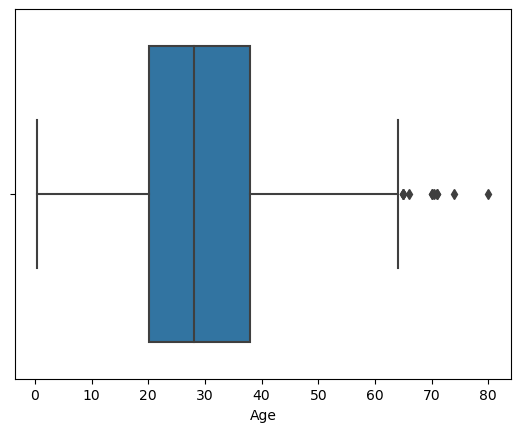

In [6]:
sns.boxplot(x=df["Age"])
plt.show()

In [7]:
# buardaki değerler programatik olarak istediğim değişken için nasıl erişeceğim problemim var
# bunu çözmeye uğraşacağım

In [8]:
# AYKIRI DEĞERLER NASIL YAKALANIR

In [9]:
# YAPMAM GEREKEN ŞEY TEORİ BÖLÜMÜNDE GÖRDÜĞÜM EİŞK DEĞERLERE ERİŞMEKTİR.
# ÖNCE YAPMAMA GEREKEN ŞEY ÇEYREK DEĞELRİN HESABINI YAPABİLMEKTİR.

In [10]:
q1 = df["Age"].quantile(0.25) #quantile 0.25 diyorum ve quantile metodu ile bu kolonun 0.25lik çeyreğini elde ediyorum 
q1 #demek ki yaş değişkenini kü.ükten büyüğe sıraladığımda 0.25lik değerdeki değer buymuş

20.125

In [11]:
q3 = df["Age"].quantile(0.75)
q3 #burada q3te bulunan değerin 38 olduğunu anladık ve artk çeyrekliklerime hakim olduğuma göre iqr değerimi hesaplayabilirim.

38.0

In [12]:
iqr = q3 - q1
iqr # iqr değerime ulaştım ve artık üst limitim için bu değeri 1.5 ile çarpıp bunun üzerin eklemem gerekmektedir.

17.875

In [13]:
up = q3 + 1.5 * iqr
up # yaş değişkenim için up limitim bu

64.8125

In [14]:
low = q1 - 1.5 * iqr
low #yaş değişkenim içim low limitim bu ancak eksi değer çıktı normlade eksi yaş olamayacağından dolayı görmezden geleceğiz.
# şimdi yapmam gereken şey alt ve üst limitin dışında olan değerleri getirmeye çalışacağım.

-6.6875

In [15]:
df[(df["Age"] < low) | (df["Age"] > up)] # | ya da demek
# alt ve üst sınır dışında kalanları getir demek istedim. Belirlediğim sınır değerler egöre aykırı değerlerde kalan veriler geldi

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.000,0,0,C.A. 24579,10.500,NaN,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.000,0,1,113509,61.979,B30,C
96,97,0,1,"Goldschmidt, Mr. George B",male,71.000,0,0,PC 17754,34.654,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.500,0,0,370369,7.750,NaN,Q
280,281,0,3,"Duane, Mr. Frank",male,65.000,0,0,336439,7.750,NaN,Q
456,457,0,1,"Millet, Mr. Francis Davis",male,65.000,0,0,13509,26.550,E38,S
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.000,0,0,PC 17609,49.504,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.000,0,0,27042,30.000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.000,0,0,C.A. 24580,10.500,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.000,1,1,WE/P 5735,71.000,B22,S


In [16]:
df[(df["Age"] < low) | (df["Age"] > up)].index #buardaki değerlerin indexlerine ulaşmak isteresem kaçıncı indexte olduklarını .index diyetek getirebilirim

Int64Index([33, 54, 96, 116, 280, 456, 493, 630, 672, 745, 851], dtype='int64')

In [17]:
#hızlı bir şekilde aykırı değer var mı yok mu diye sorak istiyorum bunu nasıl gerçekleştiririz.
# aykırı değer var mı yok mu

df[(df["Age"] < low) | (df["Age"] > up)].any(axis=None) # burada any derken herheangi bir değer var mı diye soruyoruz.
#yani burada outlier var mı diye sormaktayım. axis = None yapmak demek satır ve sütunların hepsine baktırmamı sağlıyor.

True

In [18]:
# tersini sormak için parantez içerisine alıp tilda işaretei komam gerekmekte

df[~((df["Age"] < low) | (df["Age"] > up))].any(axis=None) #bu şekilde aykırı olmayan var mı diye sormuş olurum oluyorum

True

In [19]:
df[(df["Age"] < low)].any(axis=None) #low limitim 0ın altında olduğu için ve yaş 0da nküçük olamayacağı için ve bu yüzden
#burada veri olmadığı için false döndü

False

In [20]:
#1. eşik değer belirledik.
#2. aykırılara eriştik
#3. hızlıca aykırı değer var mı diye sorduk

# bu yaptıklarımı programatik olarak yapmam gerektiği için bir sonraki bölümde bunu fonksiyon yazarak yapacağız.

# FONKSİYONLAŞTIRMA 1

In [21]:
#tüm bu yaptığım işlemleri her değişken için yapamam bu yüzden fonksiyonlaştırmam lazım. burada bu bölümün kritik noktası eşik
# değer hesaplayabilmektir.

In [22]:
# şimdi yazacağım fonksiyon kendisine girilen girilen fonksiyonun eşik değerlerini tharesoldhlarını hesaplayacak,
# ve hızlı şekilde aykırı değer var mı ile ilgili bir fonksiyon geliştireceğim, bu fonksiyonun amacı da fonksiyona değişken girildiğinde 
# bu değişkende aykırı değer var mı yok mu diye kontrol etmektir.

In [23]:
def outlier_thresholds(dataframe, col_name, q1=0.25, q3=0.75):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 -quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

burada q1 ve q3 değerleri ön tanımlı olarak verilmiş bu tanımları 5e 95 veya 1e 99 kullanmak daha çok önerilen durumlardan olabilir. ancak temel literatür 25e 75 olduğu için bu şekilde kullanıyoruz. peki ne yapılmış ilk satırda q1 hesaplatılmış daha sonrasında q3 ve bunların farkı hesaplanmış 3. satırda daha sonra up limit ve low limit hesaplatılmış ve returnn ile çıktıları döndürülmüş. return ettiğim için bunları daha sonrasında kullanabilirim.

In [24]:
#bu fonksiyonumu şimdi yaş değişkenim için çağıracağım, bruada önce bir dataframe girmem ve daha sonrasında bu dataframeden 
#bir kolon girmem lazım

outlier_thresholds(df, "Age") # buraya girilen parametrelerle ilgili eğer istersek q1 ve q3 değerleri de grebiliriz ancak eğer girmezsek ön
# ön tanımlı olduğu için eğer ön tanımlı değeri kkullanacaksak girmemize gerek yoktur.

(-6.6875, 64.8125)

In [25]:
# fare için hesaplayalı
outlier_thresholds(df, "Fare")

(-26.724, 65.6344)

In [26]:
#şimdi burada return ile döndürdüğüm değerler isaklamak istediğim için bir değişkene ataayacağım bunları

low, up = outlier_thresholds(df,"Age")
print(low, up)

-6.6875 64.8125


In [27]:
#şimdi de up ve low limiti dışında olanları getir demiştik onları getirelim
df[(df["Age"] <low) | (df["Age"] >up)].head() # artık peş peşe yapmama gereken birçok işlemden kurtuldum, up ve low limitlerine artık kolayca ulaşabiliyorum ve bu değerlerin
# dışında kalan değerlere de bu kod ile ulaşabiliyorum

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.000,0,0,C.A. 24579,10.500,NaN,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.000,0,1,113509,61.979,B30,C
96,97,0,1,"Goldschmidt, Mr. George B",male,71.000,0,0,PC 17754,34.654,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.500,0,0,370369,7.750,NaN,Q
280,281,0,3,"Duane, Mr. Frank",male,65.000,0,0,336439,7.750,NaN,Q


In [28]:
df[(df["Age"] <low) | (df["Age"] >up)].head().index
# eğer ben daha önceden yaptığım gibi bu değerlerin indexlerine erişmek istiyorsam sonuna .index yazmam yeterli olacaktır.

Int64Index([33, 54, 96, 116, 280], dtype='int64')

In [29]:
# şimdi de gidip chck_outlier fonksiyonumu yazmama gerekiyor 

def chechk_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name) #burada önceki yazdığım fnksiyonu çağırtıyorum
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True 
    else:
        return False

burada yaptığım şey diğer fonksiyonumu çağırtarak up ve low limitleri hesaplattıkran sonra buna göre any metodunu kullanarak hiç outlier değer var mı diye kontrol ediyorum. bu kısmından sonra if ve else bloğu ile eğer aykırı değer varsa True döndür eğer aykırı değer yoksa false döndür diyorum

In [30]:
chechk_outlier(df, "Age") #burada outlier olduğu için True döndürdü, burada bunu bool tipte yapmamızın nedeni
# bu fonksiyonu bir kontrol mekanizması olarak kullanarak eğer outlier değer varsa kod akışımı ona göre uyarlayabilmektir.
#  yani veriye ilk baktığımda  outlier olup olmadığını bilirsem ona göre devam edebilirim demektir.

True

In [31]:
#burada gidip Fare değişkenime göre outlier analizi yapabilirim artık çünk bir fonksiyonun içerisinde diğer 
#fonksiyon çağrılmaktadır.
chechk_outlier(df, "Fare")

True

In [32]:
#tabi burada tüm değişkenler için bunu teker teker yapamam bunun için de otommatik olarak tüm veri için sayısal değişkenlerdeki 
#outlierları kontrol edecek bir fonksiyon yazmam gerekmektedir.

# FONKSİYONLAŞTIRMA 2

grab_col_name fonksiyonunu yazacağız, neden elimde bir problem var şu an çünkü ben bunları programatik şekilde yapmak istiyorum. daha önce import ettiğim bir veri seti vardı ve ub veri setinde belirli sayısal değişkenler var. ancak ben bunları teker teker elimle seçemem, bunu programatik şekilde yapabiliyor olmam gerekiyor. bunu daha sonra katregorik veya kardinalitesi yüksek gibi vs kolonları programatik şekilde seçebiliyor olmam lazım. Öyle bir işlem yapmam lazım ki burada kategorik değişkenleri, kategorik olmayan değişşkenleri, sayısal gibi görünen kategorik değişkenleri, kategorik gibi görünen sayısal değişkenleri programatik şekilde ayırt edebiliyor olmam lazım.

In [33]:
def grab_col_names(dataframe, cat_th=10, car_th=20): #burada 10 olmak zorunda değil yoruma açıktır. kategorik olma sayısı
    # projedden projeye değişebilir yaklaşımdan yaklaşıma da değişebilir. şöyle bir yorumda bulunuyorum eğer bir değişkenin içindeki
    # sayısal değişkenin sınıf sayısı 10dan azsa bu aslında sayısal görünümlü kategorik değişken oalbilir yorumunda bulunuyorum.
    # bunu nasıl yakalayacağım, ilgili değişkenddeki eşsiz değer sayısına bak ve belirlediğim thrasholdtan küçükse ve değişkenin
    # tipi de object değilse yani numerik olarak saklanan değişkenleri yakala diyorum.
    
    #veri setindeki kategorik, numerik ve kategorik fakat kardinal değişkenlerin  isimlerini verir.
    # kategorik değişkenlerin içerisine numerik görünümlü kategorik değişkenler de dahildir.
    # sayısal görünümlü kategorik değişken nedir? değişkenlerin sayısı az ise bu değişkeni kategorik olara değerlendirebiliriz.
    # bir de kategorik olup çok fazla sınıfa sahip olup bilgi taşımayan değişkenler vardır. bunları analiz edip bulmalıyım.
    #bu fonksiyon ile numerik değişkenler, kategorik değişkenler ve kategorik gibi gözüküp ama kategorik olmayan kardinal 
    #değişkenleri ve numeric gibi gözüküp kategorik olan değişlenleri tespit etmiş olacağım.
    
    #cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "0"] #burada kategorik değişkenler seçilmiş
    
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes !="0"] #daha sonra numeric ama kategorik olanlar seçilmiş.şöyle bir yorumda bulunuyorum eğer bir değişkenin içindeki
    # sayısal değişkenin sınıf sayısı 10dan azsa bu aslında sayısal görünümlü kategorik değişken oalbilir yorumunda bulunuyorum.
    # bunu nasıl yakalayacağım, ilgili değişkenddeki eşsiz değer sayısına bak ve belirlediğim thrasholdtan küçükse ve değişkenin
    # tipi de object değilse yani numerik olarak saklanan değişkenleri yakala diyorum.
    
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > cat_th and
                   dataframe[col].dtypes =="0"] # cardinal thrashold belirlemişim, eğer bir kategorik değişkenin eşsiz değer sayısı
    # 20den(bu bir yorumdur sayı değişebilir) fazlaysa number uniq sayısı yani, ve tipi kategorikse bunları yakalayabilirim
    # bu şekilde kategorik gibi gözüküp ancak kardinal olan değişkenler yakalanır. ölçülebilirliğin yok, eşsiz çok fazla sınıfın
    # var diyorum
    
    cat_cols = cat_cols + num_but_cat # daha sonra cat_cols listemi baştan oluşturuyorum, cat_cols listeme bir de numeric gibi
    # grörünen kategorik olan değişkenleri ekliyorum.
    
    cat_cols = [col for col in cat_cols if col not in cat_but_car] # bir de cat_cols listemin içerisindeki kardinalitesi yüksek
    # değişkenler vardı bunun için kategorik değişkenlerde kardinal olmayanları seç diyorum. ve artık kategorik kolonlarım temiz
    
    
    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "0"] # tipi objectten farklı olanları getirdik
    # yani int ya da float olanlar geldi. fakat bruada  da bir problem vardı, burada da numeric gibi gözüküp kategorik olanlar
    #vardı.
    
    num_cols = [col for col in num_cols if col not in num_but_cat] #bunun için num_but_catleri num_colsun içerisinden sorgulayıp
    # bunları alma diyorum. böylece elimde de en son gerçek numericler kalmış oluyor.
    
    
    print(f"Observation: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}") 
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")
    return cat_cols, num_cols, cat_but_car #numeric_but_catler catcols içinde olduğu için ekstradan çağırmıyorum.

#bu fonksiyon bana benim göz ile yapamayacağım bazı imkanlar sağlıyor.

In [34]:
def grab_col_names(dataframe, cat_th=10, car_th = 20): #cat değişkenler için trash hol değeri giriyorum aynı şeyi kardinal değişkenler için de yapıyorum
    # eğer bir değişken sayısal olsa bile ona eğer değişken sayısı 10dan küçükse kategorik değişken muamelesi yapılacak, eğer kategorik değişkenin de değişken 
    #sayısı 20den büyükse buna kardinale değişken muamelesi yapılacak
    #docstring fonksiyona argüman yazma meselesidir.
    """
    buraya docstring yazılacak
    pycharmda otoatik olarak var
    ilk olarak fonk ne görev yapacak altına da parametreler yazılır ve tip verisi verilir önce
    sona da returnunde ne olacak yazıyorum çıktısında ne olacak
    en sona da not eklenebilir problemin ne olduğuna ve toplam değişkene dair
    
    """
    #kategorik değişkenleri oluşturacak bölüm
    cat_cols =[col for col in df.columns if str(df[col].dtypes) in ["category", "object", "bool"]]
    
    num_but_cat =  [col for col in df.columns if df[col].nunique() < 10 and df[col].dtypes in ["int64","float64"]]
    
    cat_but_car = [col for col in df.columns if df[col].nunique() > 20 and str(df[col].dtypes) in ["category","object"]]
    
    cat_cols = cat_cols + num_but_cat
    
    cat_cols = [col for col in cat_cols if col not in [cat_but_car]]
    
    #sayısal değişkenleri oluşturacak bölüm
    num_cols = [col for col in df.columns if df[col].dtypes in ["int64", "float64"]]
    
    num_cols = [col for col in num_cols if col not in cat_cols]
    
    #birkaç raporlama bölümü ekliyorum
    
    print(f"Observations: {dataframe.shape[0]}") #shapein 0nda satır sayısı
    print(f"Variables: {dataframe.shape[1]}") #1nde kolon(değişken sayısı) vardır
    print(f"cat_cols: {len(cat_cols)}") #oluşturudğum kat değişkenlerinin boyutunu cal_cols şeklinde alıyorum
    print(f"num_cols: {len(num_cols)}") #umerik değişkenlerin boyutu
    print(f"cat_but_cardi: {len(cat_but_car)}") #aynıları
    print(f"num_but_cat: {len(num_but_cat)}")
    
    return cat_cols, num_cols, cat_but_car #numbutcat catcolsun içinde zaten
    
    

In [35]:
dff = pd.read_csv("titanic.csv")
cat_cols, num_cols, cat_but_car = grab_col_names(df)
# burada num_cols = 3 
#cat_but_car =3 
#num_but_cat = 4 olmalı diğerleri olduğu gibi olacak
# sonuncusu sadece raporlamak için yapılmıştır ve zaten categoriğin içindedir.

Observations: 891
Variables: 12
cat_cols: 9
num_cols: 3
cat_but_cardi: 3
num_but_cat: 4


In [36]:
cat_cols #göz yordamıyla yakalayamadığım categorik deişkenleri bile yakalamış oldum bu sayede değişlenlerimi sınıflandırmış
# oluyorum.

['Name',
 'Sex',
 'Ticket',
 'Cabin',
 'Embarked',
 'Survived',
 'Pclass',
 'SibSp',
 'Parch']

In [37]:
num_cols
#burada sadece Fare , age, passengerid olmalı, passengeridyi atacağım buradan

['PassengerId', 'Age', 'Fare']

In [38]:
num_cols = [col for col in num_cols if col not in "PassengerId"]

In [39]:
"""num_cols = [col for col in num_cols if col not in "Name"]
num_cols = [col for col in num_cols if col not in "Ticket"]
num_cols = [col for col in num_cols if col not in "Cabin"]"""

'num_cols = [col for col in num_cols if col not in "Name"]\nnum_cols = [col for col in num_cols if col not in "Ticket"]\nnum_cols = [col for col in num_cols if col not in "Cabin"]'

In [40]:
num_cols # elimle diğerlerini atıyorum çünkü istediğim sonuçta bu değişkenler yok, fonksiyon tam düzgün çalışmıyor
#daha sonrasında bu fonksiyona bakacağım.

['Age', 'Fare']

In [41]:
"""cat_but_car = [col for col in df.columns if col in ["Name", "Ticket", "Cabin"]] # direkt dfden ekledim"""

'cat_but_car = [col for col in df.columns if col in ["Name", "Ticket", "Cabin"]] # direkt dfden ekledim'

In [42]:
cat_but_car

['Name', 'Ticket', 'Cabin']

In [43]:
#şidmi buradaki veiye check_outlier fonksiyonumu soracağım

for col in num_cols:
    print(col, chechk_outlier(df,col)) #outlier bulunmaktaymış

Age True
Fare True


In [44]:
#büyük veri setlerinde grab_col_name fonksiyonu işimi çok kolaylaştıracağı için bana çok fazla bir zaman tasarrufu sağlayacak

In [45]:
#şimdi yeni problemim aykırı değerler var ancak bunların kendisine nasıl ulaşacağım.

# AYKIRI DEĞERLERE ERİŞMEK

In [46]:
#Aykırı değerlerin kendisine erişmek için ne yapmam gerekiyor buna bakacağım. burada aykrı değerleri yakalamak bir iş,
#bu yakaladığım değerlerin kim olduğuna gibip bakmak ayrı bir iş ve bunları fonksiyonel olarak yapmam lazım.

In [47]:
# yazacağım fonksiyonda eğer ondan fazla aykırı değer varsa bana bunları head atarak getirsin, eğer ondan azsa hepsin getirsin 
# gözlemleyebilmek adına.

In [48]:
def grab_outliers(dataframe, col_name, index = False): #df ismi gireceğiz, col name gireceğiz, ilgili outlierların indexlerine 
    #default olarak false yapıyoruz çünkü başta istemiyoruz. index açıksa if index fonksiyonu çalışabilecek.
    low, up = outlier_thresholds(dataframe, col_name)
    
    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
        # eğer alt limitten küçük veya üst limitten büyük olanlar varsa getir ve bu getirdiklerinin sayısı shape[0]ın sayısını
        # baz alarak 10dan büyükse headini al.
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])
        # 10dan büyük değilse hepsini getir. azmış zaten diyorum.
        
    
    if index:
        outlier_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        # burası daha detaylı analiz yapabilmek için eğer açılırsa indexlerini getirecek. 
        return outlier_index

In [49]:
grab_outliers(df,"Age") #10dan büyük olduğudan dolayı  sadece headini aldı

     PassengerId  Survived  Pclass                            Name   Sex    Age  SibSp  Parch      Ticket   Fare Cabin Embarked
33            34         0       2           Wheadon, Mr. Edward H  male 66.000      0      0  C.A. 24579 10.500   NaN        S
54            55         0       1  Ostby, Mr. Engelhart Cornelius  male 65.000      0      1      113509 61.979   B30        C
96            97         0       1       Goldschmidt, Mr. George B  male 71.000      0      0    PC 17754 34.654    A5        C
116          117         0       3            Connors, Mr. Patrick  male 70.500      0      0      370369  7.750   NaN        Q
280          281         0       3                Duane, Mr. Frank  male 65.000      0      0      336439  7.750   NaN        Q


In [50]:
age_index = grab_outliers(df,"Age", True)
age_index

     PassengerId  Survived  Pclass                            Name   Sex    Age  SibSp  Parch      Ticket   Fare Cabin Embarked
33            34         0       2           Wheadon, Mr. Edward H  male 66.000      0      0  C.A. 24579 10.500   NaN        S
54            55         0       1  Ostby, Mr. Engelhart Cornelius  male 65.000      0      1      113509 61.979   B30        C
96            97         0       1       Goldschmidt, Mr. George B  male 71.000      0      0    PC 17754 34.654    A5        C
116          117         0       3            Connors, Mr. Patrick  male 70.500      0      0      370369  7.750   NaN        Q
280          281         0       3                Duane, Mr. Frank  male 65.000      0      0      336439  7.750   NaN        Q


Int64Index([33, 54, 96, 116, 280, 456, 493, 630, 672, 745, 851], dtype='int64')

Ağaca dayalı yöntemlerin çoğu outier değerlere duyarsızdır, eksik ve aykırı değerler göz ardı edilir. edilmelidir.

In [51]:
#kafamız karışmasın 3 tane şey yaptık,

outlier_thresholds(df, "Age")
chechk_outlier(df, "Age")
grab_outliers(df,"Age", True)

#şu ana kadar aykırı değerleri yakaladım.

     PassengerId  Survived  Pclass                            Name   Sex    Age  SibSp  Parch      Ticket   Fare Cabin Embarked
33            34         0       2           Wheadon, Mr. Edward H  male 66.000      0      0  C.A. 24579 10.500   NaN        S
54            55         0       1  Ostby, Mr. Engelhart Cornelius  male 65.000      0      1      113509 61.979   B30        C
96            97         0       1       Goldschmidt, Mr. George B  male 71.000      0      0    PC 17754 34.654    A5        C
116          117         0       3            Connors, Mr. Patrick  male 70.500      0      0      370369  7.750   NaN        Q
280          281         0       3                Duane, Mr. Frank  male 65.000      0      0      336439  7.750   NaN        Q


Int64Index([33, 54, 96, 116, 280, 456, 493, 630, 672, 745, 851], dtype='int64')

In [52]:
grab_outliers(df,"Age")

     PassengerId  Survived  Pclass                            Name   Sex    Age  SibSp  Parch      Ticket   Fare Cabin Embarked
33            34         0       2           Wheadon, Mr. Edward H  male 66.000      0      0  C.A. 24579 10.500   NaN        S
54            55         0       1  Ostby, Mr. Engelhart Cornelius  male 65.000      0      1      113509 61.979   B30        C
96            97         0       1       Goldschmidt, Mr. George B  male 71.000      0      0    PC 17754 34.654    A5        C
116          117         0       3            Connors, Mr. Patrick  male 70.500      0      0      370369  7.750   NaN        Q
280          281         0       3                Duane, Mr. Frank  male 65.000      0      0      336439  7.750   NaN        Q


# AYKIRI DEĞER PROBLEMİN ÇÖZME

In [53]:
low, up = outlier_thresholds(df,"Fare")

In [54]:
low

-26.724

In [55]:
up

65.6344

In [56]:
df.shape

(891, 12)

In [57]:
# tesine gideceeğiz limitlerin dışında olmayanları getir demeye çalışıyorum.

In [58]:
df[~((df["Fare"] < low) | (df["Fare"] > up))].shape #burada aykırı değerlerin dışındaki değerleri görebiliyorum bu  da 
#bana aykırı değeler silindikten sonra ne kadar gözlem kalacağını söylemiş olacak.

(775, 12)

In [59]:
#elimdeki tüm değişkenler için teker teker bunu yapmama ve bunun için bir fonksiyon yazmam gerekmektedir.

def remove_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    df_without_outliers = dataframe[~((dataframe[col_name] < low_limit) | (dataframe[col_name] > up_limit))]
    return df_without_outliers
# alt ve üst limit sınırların dışında kalanları getiriyorum bunu yeni bir değişkene atıyorum ve burada outlier
#fonksiyonumu çağırıyorum

In [60]:
#bu işlemi fare ve age değişkenim için gerçekleştireceğim ancak bunları programatik şekilde gerçekleştirelim.

In [61]:
df.shape

(891, 12)

In [62]:
for col in num_cols:
    new_df = remove_outlier(df, col)

In [63]:
df.shape[0] - new_df.shape[0] #eski df ile yeni df arasındaki farkı buluyorum ve kaç tane gözlem silindiğine ulaşmış oluyorum.

116

Veri silerken dolu olan verilerimizden de olmuş oluyoruz ve bazen silmek yerine baskılama yöntemini de kullanabiliyoruz.

In [64]:
# Baskılama Yöntemi (re- assignment with thresholds)

#baskılama yöntemi şu şekilde çalışıyor, eşik değerlerin üzerinde kalan değerler eşik değerler ile değiştirilir.
#silme yönteminden ortaya çıkacak kaybı yok etmiş oluruz veri kaybetmek istemediğimizde kullanırız.

In [65]:
low, up =outlier_thresholds(df, "Fare")

In [66]:
df[((df["Fare"] < low) | (df["Fare"] > up))]["Fare"] # burada fare değişkeni için aykırı değerler var.

1      71.283
27    263.000
31    146.521
34     82.171
52     76.729
61     80.000
62     83.475
72     73.500
88    263.000
102    77.287
118   247.521
120    73.500
124    77.287
139    79.200
151    66.600
159    69.550
180    69.550
195   146.521
201    69.550
215   113.275
218    76.292
224    90.000
230    83.475
245    90.000
256    79.200
257    86.500
258   512.329
262    79.650
268   153.463
269   135.633
275    77.958
290    78.850
291    91.079
297   151.550
299   247.521
305   151.550
306   110.883
307   108.900
310    83.158
311   262.375
318   164.867
319   134.500
324    69.550
325   135.633
332   153.463
334   133.650
336    66.600
337   134.500
341   263.000
366    75.250
369    69.300
373   135.633
375    82.171
377   211.500
380   227.525
385    73.500
390   120.000
393   113.275
412    90.000
435   120.000
438   263.000
445    81.858
453    89.104
484    91.079
486    90.000
496    78.267
498   151.550
504    86.500
505   108.900
520    93.500
527   221.779
537   

In [67]:
# yukarıda yaptığım işlemi loc ile de yapabilirim.

df.loc[((df["Fare"] < low) | (df["Fare"] > up)), "Fare"] #loc yapısı ile belirli bir değerden küçük ya da büyük olan değerleri
# getir demiş oluyorum.

1      71.283
27    263.000
31    146.521
34     82.171
52     76.729
61     80.000
62     83.475
72     73.500
88    263.000
102    77.287
118   247.521
120    73.500
124    77.287
139    79.200
151    66.600
159    69.550
180    69.550
195   146.521
201    69.550
215   113.275
218    76.292
224    90.000
230    83.475
245    90.000
256    79.200
257    86.500
258   512.329
262    79.650
268   153.463
269   135.633
275    77.958
290    78.850
291    91.079
297   151.550
299   247.521
305   151.550
306   110.883
307   108.900
310    83.158
311   262.375
318   164.867
319   134.500
324    69.550
325   135.633
332   153.463
334   133.650
336    66.600
337   134.500
341   263.000
366    75.250
369    69.300
373   135.633
375    82.171
377   211.500
380   227.525
385    73.500
390   120.000
393   113.275
412    90.000
435   120.000
438   263.000
445    81.858
453    89.104
484    91.079
486    90.000
496    78.267
498   151.550
504    86.500
505   108.900
520    93.500
527   221.779
537   

In [68]:
df.loc[(df["Fare"] > up), "Fare"] = up # üst sınıra göre Fare değişkenini getir diyorum ve eşittir up dersem bu değerler yerine 
# up limitlerini basmış oluyorum.

In [69]:
df.loc[(df["Fare"] > up), "Fare"] #bunu birdaha çalıştırıp bakıorum ve boş geliyor çünkü artık üst limitin üstünde değer yok.

Series([], Name: Fare, dtype: float64)

In [70]:
# bunu alt limit için de yapmam gerekiyor ancak alt limitten zzaten değerim olayacağı için şu anda yok.
df.loc[(df["Fare"] < low), "Fare"] = low
# o yüzden şu anda lowu basmam bir şey değiştirmeyecek ama sonra yapmama gerekeceği için burada bırakıyorum.

# o zaman bunu programatik olarak yapabilirim artık.

In [71]:
def replace_with_thresholds(dataframe, variable):
    low_limit , up_limit = outlier_thresholds(dataframe, variable) #utlier thresholds bana limitleri versin
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit
    
    # daha sonra alt limitten aşağıda olan değerleri alt limitle
    # üst limitten yukarıda olan değerleri üst limitle değiştirelim.

In [72]:
df = pd.read_csv("titanic.csv")
df.shape

(891, 12)

In [73]:
#öncelikle outlier var mı yok mu diye soracağım

for col in num_cols:
    print(col, chechk_outlier(df, col))

Age True
Fare True


In [74]:
# daha sonra replaec fonksiyonumu getirelim ve her bir değişken için değerlerin thresholdlarıyle değerleri değiştirelim.

for col in num_cols:
    replace_with_thresholds(df, col)

In [75]:
#tekrar soruyorum

for col in num_cols:
    print(col, chechk_outlier(df, col))
    
    #artık yok problem ortadan kalkmış oldu.

Age False
Fare False


# ÇOK DEĞİŞKENLİ AYKIRI DEĞER ANALİZİ
# (LOCAL OUTLİER FACTOR)

çok değişkenli aykırı değer ne demek sorusuna yanıt verelim. diyelim ki elimizde 2  tane değişken var ve 1.si yaş değişkeni olsun 2.si ise evlilik sayısı değişkeni olsun. evlilik sayısı değişkenine odaklanmış olursak...

burada anlatılmak istenen tek başına bakıldığınd aykırı bir değermiş gibi durmayan değerlerin birleştiğinde aykırı bir değer oluşturmasından kayanklanmaktadır. 
örneğin 17 yaşında 3 evlilik yapmış biri gibi.Burada anormallik olacağı için bu bir aykırı değerdir. yani buradan sonuçla aykırı değerlere çok değişkenli olarak da bakmak da önemlidir. buna çok değişşkenli etki denir. tek başına anlamlı olamayacak yapılar çok değişkenli şekilde anlamlı hale gelebilir. örneğimizede olduğu gibi outlier hale gelebilir.

# LOF YÖNTEMİ NEDİR

GÖRSEL ÜZERİNDEN AÇIKLIYOR. lof yötemi ne yapar? gözlemleri bulundukları konumda yoğunluk tabanlı şekilde skorlayarak buna göre aykırı değer olabilecek değerleri tanıma imkanı sağlar. burada bir noktanın local yoğunluğu demek ilgili noktanın etrafındaki yoğunluklar demektir. yani nokta etrafından belirli bir mesafe ile bir daire çizilir ve bu dairenin etrafında kalanlar o noktanın local yoğunluğudur, komşularıdır. eğer bir noktanın komşuluğu diğer noktlaardan düşükse bu nokta daha seyrek bir bölgededir yani aykırı değer olabilir diyebiliriz.

inlier kavramını değerlendirelim. lof yönteminde benim size verdiğim skor 1e ne kadar yakınsa o kadar iyidir der. bu yüzden ilgili gözlemin skoru 1den ne akdar çok uzaklaşırsa outlier olma ihtimali o kadar artar. burada görülen küçük kırmızı noktalar inlier değerleri göstermektedir. lof yöntemindeki kritik noktalardan biri threshold değeridir. eğer ben eşik değerimi yüksek belirlersem örneğin 5 gibi, outlier değerlerimin sayısı düşücektir. yani threshold değeri ile müdahele edebilme imkanı sağlanıyor lof yönteminde.

peki elimdeki 100 değişkenli bir gözlemi nasıl görselleştirebilirim? bu bir mülakat sorusudur. bunu pca, temel bileşen analizi yöntemi ile gerçekelşetirebiliriim. çünkü elimdeki 100 değişkenli gözlemin büyük bir kısmının taşıığı bilgiyi eğer 2 boyutlu bir görsele indirgeyebilirsem bu şekilde görselleştirebilirim. yani burada gözlemimin en çok bilgi taşıyan 2 değişkeni ile bunu yapabilme imkanım var, eğer yeterli bilgiyi taşıyorlarsa. normalde bu gözlemi görselleştiremem çünkü çok fazla değişken var.

In [76]:
#hızlı bir öenk yapalım

In [77]:
df = sns.load_dataset("diamonds") #diamond dataseti çağırdım
df = df.select_dtypes(include=["float64", "int64"]) # sadece sayısal verilerini istiyorum
df = df.dropna() #boş değerlerini sildim
df.head() # ilk 5 gözlem

,carat,depth,table,price,x,y,z
0,0.230,61.500,55.000,326,3.950,3.980,2.430
1,0.210,59.800,61.000,326,3.890,3.840,2.310
2,0.230,56.900,65.000,327,4.050,4.070,2.310
3,0.290,62.400,58.000,334,4.200,4.230,2.630
4,0.310,63.300,58.000,335,4.340,4.350,2.750


In [78]:
df.shape

(53940, 7)

In [79]:
# buardaki lof yöntemini ortaya çıkarak bir örnek değerlendiriyor olacağız. check_outlier fonk getirip soralım aykırı değer var mı?

In [80]:
for col in df.columns:
    print(col, chechk_outlier(df,col)) # outlier var gibi gözüküyor

carat True
depth True
table True
price True
x True
y True
z True


In [81]:
# bu değişkenlerden sadece birini seçsem mesela karat değişkeni ve kaç tane outlier değer var merak ediyor olsam.

low, up = outlier_thresholds(df, 'carat')

In [82]:
df[((df["carat"] < low) | (df["carat"] > up))].shape #1889 tane outlier değer var gibi gözüküyor 53940 adet veride 

(1889, 7)

In [83]:
#başka bir gözlem seçiyorum ve ona bakıyorum

low, up = outlier_thresholds(df, 'depth')
df[((df["depth"] < low) | (df["depth"] > up))].shape #2545 adet aykırı gözlem varmış.

(2545, 7)

burada literatürdeki gibi 25e 75 kullanmış olsaydık ve silseydik ciddi bir veri kaybı oluşturmmuş olacaktık. bunun yerine doldurmuş olsaydık da tortu yaratmış olacaktık, kendi kendimize veriye gürültü eklemiş olacaktık ancak ağaç yöntemleri kullanıyorsak hiç dokunmamayı tercih edebiliriz ya da çok az ucundan kırpabiliriz, ekstra ekstra aykırı olanları silebiliriz. bunun yerine 5e 95 kullanmak daha mantıklı oluyor.

buaradki gözlemlerde tek başına baktığımızda çok yüksek sayıda aykırılıklar geldi. bakalım çok değikenli şekilde yaklaştığımızde neler olacak.

In [84]:
#localoutlier factor metodunu getiriyorum

clf = LocalOutlierFactor(n_neighbors=20) #burada komşuluk sayısını 20 yapıyorum, bu komşuluk sayısı değişebilir 5 olabilir 10 olabilir duruma göre değişebilri.
#broutforce dediğimiz şeyi yaparak buradaki komşu sayısını bir döngü ile değiştirebiliriz. ancak buradaki problm komşuluk sayılarını denedikten sonra
# hangisinin daha iyi olacağını yorumlayamayacak olmanızdır. dolayısıyla buraad localoutlierfactor metodunun ön tanımmlı değeri olan 
#20yi kullanmak daha mantıkldır.

In [85]:
#şimdi bu yöntemi verisetime uygulamam gerekiyor

clf.fit_predict(df) # fit_predict dediğimde skorları getiriyor olacak. yani localoutlierfactor skorlarını getiriyor olacak.

array([-1, -1, -1, ...,  1,  1,  1])

In [86]:
#burada takip edilebilirlik açısından negativeoutlierfactor diyerek skorlarımı tutuyorum.

df_scores = clf.negative_outlier_factor_ #yani burada predict ettikten sonra skorları tutan bölüm burası. nedir bu peki mesela 5
# tanesini gözlemleyelim.

In [87]:
df_scores[0:5] # dikkat bunlar lof skorlarıdır, kullanılan metod bunları bize eksi değerlerle verdi, dolayısıyla bunları
# eksi değerlere göre değerlendiriyor olacağız.

array([-1.58352526, -1.59732899, -1.62278873, -1.33002541, -1.30712521])

In [88]:
# bunu eksi değerlerle değerlendirmek istemezsek başınaeksi koyup atarız.

#df_scores = -df_scores
df_scores # ancak bunu fonksiyonun bize verdiği orijinal haliyle kullanmayı tercih edeceğiz. bunun sebebi eşik değere karar vermek için
# kullanıcı olarak bir bakış gerçekleştirmek istediğimizde oluşturacak olduğumuz elboy yöntemi yani dirsek yöntemi grafik tekniği ile
#daha rahat okunabilirlik açısından eksi olarak bırakacağız.

array([-1.58352526, -1.59732899, -1.62278873, ..., -1.06721815,
       -1.00809552, -1.00849038])

burada gözlemler negatif olduğu için artık -1 durumuna yaklaşmasını isteyeceğim, artık -1 durummu inlier olduğunu göstermektedir. yani artık -1den ne kadar uzaklaşırsak o kadar outlier olma durummunu yorumlayacağız.

In [89]:
#şimdi bu değerleri küçükten büyüğe sıralayarak en kötü 5 skoru görmeye çalışalım.

np.sort(df_scores)[0:5]

array([-8.60430658, -8.20889984, -5.86084355, -4.98415175, -4.81502092])

<Axes: >

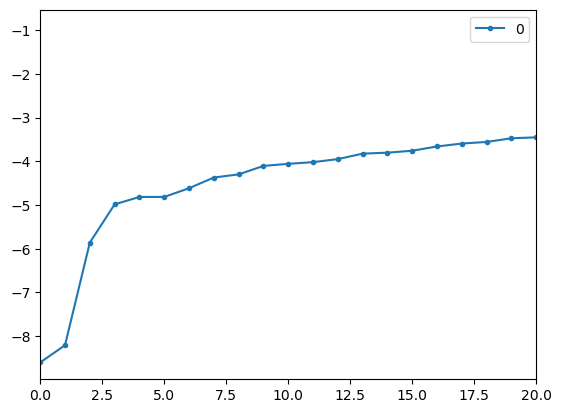

In [90]:
#burada artık bir eşik değeri belirliyor olmamız gerekmektedir. burada bir yorum alanı vardır. ancak ben bunu pca'da kullanılan bir 
# dirsek yöntemi ile belirleyebileceğimi biliyorum. bu yönteme göre bunu belirleyebilirim.

scores = pd.DataFrame(np.sort(df_scores))
scores.plot(stacked=True, xlim=[0, 20], style=".-")

buradaki her bir nokta eşik değerleri temsil etmektedir. bu eşik değerler egöre grafik oluşturulmuştur. buradaki eşik değer ne olmalı problemim var. bu noktalar dikkatli incelenirse en net eğim değişikliğinin olduğu nokta -6dan -5e geçerken olan noktadır. dolayısıyla şu yorumu yapabilirim, en marjinal değişiklik burada olduğu için eşik değerimi bu nokta olarak belirleyebilirim. ondan sonraki noktaların daha düşük değişiklikler içerdiğini görebiliyorum. bu yöntem ile en son yaşanan büyük değişmi baz almam gerekmektedir. başka bir yeride belirleyebilirim ben şu anda sondan 20 tanesini belirledim. genişletip tekrar gözlemleyebilirim.

<Axes: >

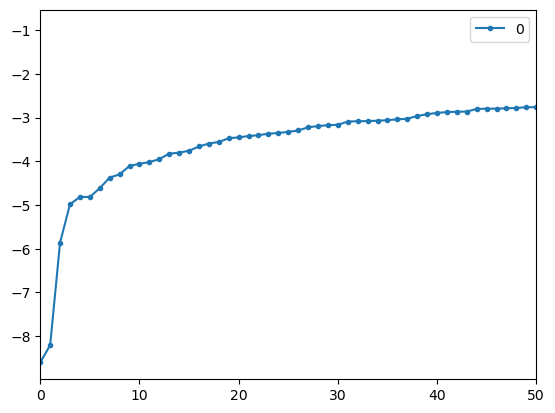

In [91]:
scores.plot(stacked=True, xlim=[0, 50], style=".-")

burada outlier skorlarını görebiliyorum 50 adet, bakıyorum burada marjinal farklılıklar çok düşük olduğu için 3. indexteki değişikliği seçebilirim.

In [92]:
#şimdi threshold değeri oluşturacağım

th = np.sort(df_scores)[3]
th #eşik değerimi belirledim.

-4.984151747711709

şimdi bu eşik değeri kullnaark bu eşik değerinden düşük olanları seçebilirim. artık bundan daha eksilerde olanları aykırı değer olarak belirleyeceğim.

In [93]:
df[df_scores < th] # eşik değerimden düşük olan gözlemleri getiriyorum

,carat,depth,table,price,x,y,z
41918,1.030,78.200,54.000,1262,5.720,5.590,4.420
48410,0.510,61.800,54.700,1970,5.120,5.150,31.800
49189,0.510,61.800,55.000,2075,5.150,31.800,5.120


In [94]:
df[df_scores < th].shape #shape ile de gözlemleyebilirim.

#dikkat burada lofu pekiştireceğim noktalardaım, bu değerler neden aykırı bilmiyorum. normalde incelediğim değişkenlerde 1000den fazla aykırı değer  yaklanamıştı.
# şimdi sadece 3 tane geldi. daha önceden binlerce varken şimdi lof ile çok değişkenli yöntme baktığımda sadece 3 tane kaldı.
#şimdi bunların neden aykırı olduğunu anlmaaya çalışacağım. tek başına baktığımda binlerce gelen aykırılıklar lof ile baktığımda 
# sadece 3 adete indi

(3, 7)

In [95]:
df.describe([0.01, 0.05, 0.75, 0.90, 0.99]).T

,count,mean,std,min,1%,5%,50%,75%,90%,99%,max
carat,53940.000,0.798,0.474,0.200,0.240,0.300,0.700,1.040,1.510,2.180,5.010
depth,53940.000,61.749,1.433,43.000,57.900,59.300,61.800,62.500,63.300,65.600,79.000
table,53940.000,57.457,2.234,43.000,53.000,54.000,57.000,59.000,60.000,64.000,95.000
price,53940.000,3932.800,3989.440,326.000,429.000,544.000,2401.000,5324.250,9821.000,17378.220,18823.000
x,53940.000,5.731,1.122,0.000,4.020,4.290,5.700,6.540,7.310,8.360,10.740
y,53940.000,5.735,1.142,0.000,4.040,4.300,5.710,6.540,7.300,8.340,58.900
z,53940.000,3.539,0.706,0.000,2.480,2.650,3.530,4.040,4.520,5.150,31.800


şidmi incelemem başlıyorum teker teker bakyorum caratta çok anormal bir durum yok gibi ortalama ve maks değerinde, 
gidip dephe bakıyorum maks değerin e79, burada radaraıma takıldı, burada aslında iki konu var gözleme baktığımda 78.200 değeri gözüküyor ancak maks değer 79.000. ancak buna bu sebep olamuş olabilir maksimuma yakın olduğu için diye değerlendirebilirim. tabel değerine bakıyorum ort ve maks değerlerine tamam olabilir diyorum. diğerlerini de kontrol ettiğimde beklenti içerisinde olduğunu görebiliyorum. ancak ilk satırda bir terslik olduğunu biliyorum ve yakalanma sebebinin deph olduğunu düşünüyorum. ama yeni bir problem var neden 79 değil de 78200 geliyor diyorum ya da neden sadece 78200. ya dadiyorum ki fiyatı 1262 olup derinliği 78200 olma durumu etki göstermiş olabilir diyorum. yani edrinliği 78.200 olup caratı 1.030 ve fiyatı 1262 olamaycak olanlar olabilir ya da olabilecek olanlar olabilir, bir şekilde burada çok değişkenli etkiden geldiğini anlayabiliyorum.


gidip ikinci satıra bakıyorum z dışında diğerleri normalken aralıklar arasındayken z değişkenine baktığımda ortalamanın 3 olduğunu ancak gelen satırın değerinin 31 olduğunu görüyorum ve bu yüzden geldiğini anlıyorum, burası zaen maks değeri, ancak tek bu yzüden mi geldi emin olamıyorum, muhtemelen z özelliği bu şekilde olup diğer özellikleri bu şekilde olamayacağından dolayı bu satır yakalandı.

bu şekilde analiz yorumlarımı yapmam gerekmektedir.

In [96]:
# peki bunları ne yapacağım, öncelikle index bilgilerini yakalayabilirim.

df[df_scores <th].index

Int64Index([41918, 48410, 49189], dtype='int64')

In [97]:
# daha sonra bunları istersem silebilirim. 

df[df_scores <th].drop(axis=0, labels=df[df_scores <th].index)
# axisi 0 yapıyorum, labellerı az önce getirdiğim indexlerden getiriyorum. ve drop ediyorum. siliyorum ve kurtuluyorum.
# az oldğu için problem olmaz ancak baskılama yöntemini de denyebilirim.

,carat,depth,table,price,x,y,z


ancak baskılamak istediğimde bir problem var kimle baskılayacağım. herhangi bir gözlem seçip ortalama değer ile baskılayabilirim. yani aykırı değerleri bu değer ile değiştirebilirim. bu enaryo için 3 tane gözlem olduğundan problem olmayacaktır. zaten gözlem sayısı az. ancak yüzlerce değer hesaplanmış olsa threshold değerine göre, bu şöyle olacak o zaman, yüzlerce aynı değeri baskılamış olacağım th dğerine göre. artık gözlem birimleriyle ilgilendiğim için bir gözlem birimine göre aykırılığı komple kaldırıp yerine başka bir gözlem koymam gerekmektedir. buarda problem kendi elimle çok fazla sentetik veri üretmekten kaynaklanır, kendi elimle veriyi bozmamdan kaynaklanmaktadır. dolayısıyla th değeri fazlaysa değiştirmek baskılamak gibi şeyler yapmak ciddi problemlere sebep olabilecektir. o zaman ne yapacağız. eğer ağaç yöntemleri ile çalışıyorsak bulara hiç dokunmayacağız. ya da en ucundan traşlayacağız. eğer fazlasysa veri setinden çıkarmak daha sağlıklı olacaktır. ancak doğrusal yöntemler kullanıyorsak aykırı değerler problemi ciddi şekilde benim için devam etmektedir. doldurmak yerine azsa silmek tercih edilebilir, ya da çoksa tek değişkenli olarak baskılamak tercih edilebilir yine ucundan.

# 2 ) MİSSİNG VALUES

# EKSİK DEĞERLER (MİSSİNG VALUES)

gözlemlerde eksiklik olma durumunu ifade etmektedir. eksik değerleri çözmek odaklanacak olduğumuz problem çözme yöntemlerinden biri olacaktır. yaygınca kullanılan 3 ana yöntemi inceleyeceğiz.
* 1. silme
* 2. değer atama yöntemleri  (ort, mod, medyan atama yöntmeleri gibi)(basit atama yöntemleri)()bunlar tahminsel değildir.
* 3. tahmine dayalı yöntemler (bazı istatisel yöntemler ya da machine learning yöntemleri gibi)


"eksik değer atama yöntemi hem tehlikeli hem de çekii bir yöntemdir."
peki neden bu şekilde bir söz var. eksik veriyle çalışırken eksik verinin göz önünde bulundurulması gereken bir konu var çünkü, eksik verinin rassallığı konusudur. yani eksik verinin rastgele çıkıp çıkmadığı durumunun bilinmesidir.

söz = eksik değere sahip gözlemlerin veri setinden direkt çıkarılması ve rassallığının incelenmemesi, yapılacak istatiksel çıkarımların ve modelleme çalışmalarının güvenirliliğini düşürecektir.(çok değişkenli istatiksel yöntemler kitabından)

söz = eksik gözlemlerin veri setinden direkt çıkarılabilmesi için veri setindeki eksikliğin bazı durumlarda kısmen bazı durularda tamamen rastlantısal olarak oluşmuş olması gerekmektedir. eğer eksiklikler değişkenler ile ilişkisel olarak ortaya çıkan yapsal problemler ile meydana gelmiş ise bu durumda yapılacak silme işlemleri ciddi yanlılıklara sebep olabilecektir.(tabachknick kitabından)


yani değişkenlerin oluşmamasının bir sebebi varsa ve bir problemden kaynaklandıysa bunu tespit etmek gerekmektedir. ancak gerçekten rastlantısal ise bunları rahatlıkla silebiliriz. örn bir kişinin kredi kartı yoksa bu kişinin zaten kredi kartı harcaması olmadığından oradaki veri nan gelecektir. işte buna bir değişkendeki eksiklik başk bir değişkenin etkisiyle ortaya çıkmıştır denmektedir. kredi kartı olma durumu 0 olduğundan dolayı diğer değişkenlerdeki veriler de nan gelecektir. yani kredi kartındaki eksiklikler rastgele değildir. peki biz bunu ne yapacağız. burası juniorlar ile seniorların ayrıldığı yerdir. burası biz geliştiriciler için göz önünde bulundurmamız gereken bir nokta, çeşitli yöntemler kullanrak keşfediyoruz ki belirli bir değişkenle aralarında bir bağlantıdan dolayı bu eksiklik ortaya çıkmış olabilir. bu durumu biliyor olacağız, eğer eksiklikleri doldurmaya karar verirsek ve eksikliklerin rastgele oluşmadığını bilirsek b udurumda yapacağımız işlemlerin ortaya bazı problemler çıkarabileceğini bilmemiz gerekir. bu yapısallığın nereden kaynaklandığını çözmemiz gerekmektdir.

# EKSİK DEĞERLERİ YAKALAMA

In [98]:
def load():
    df = pd.read_csv("titanic.csv")
    return df


In [99]:
df = load()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


In [100]:
#veri setimde hızlıca eksik değer var mı yok mu bunu öğrenmek istiyorum

df.isnull().values.any() #dediğimde bu soruyu sormuş olurum.

#burad aisnull tüm hücreleri gezer ve bak bakalım eksiklik var mı der. True ya da false yanıtları gelir burada 
# yanıtları values ile tutarız, any ile de hangiisnde eksiklik varsa bunu getir demiş oluruz.
# burada tüm veriye eksiklik var mı diye sorduk ve yanıtımızı aldık.

True

In [101]:
#değişkenlerdeki eksik değer sayısını bulmak istediğimizde nasıl yapacağız. hangi değişkende kaç eksik değer var

df.isnull().sum() #isnulla yine tur false gelir ve bunu sum ile toplarsam olur.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [102]:
#peki boş yerine dolu olanların sayısını öğrenmek istersem 

df.notnull().sum() #bu şekilde de dolu olan değerleri geitrmiş olurum.

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

In [103]:
# veri setindeki toplam boş veri sayısına erişmek istersek 

df.isnull().sum().sum()

866

In [104]:
#en az bir tane eksik değere sahip olan gözlem birimleri

df[df.isnull().any(axis=1)] #an az bir satırda bile eksik değer varsa bu gözlem birimleri gelecek

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.458,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000,3,1,349909,21.075,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000,0,2,347742,11.133,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000,1,0,237736,30.071,NaN,C
12,13,0,3,"Saundercock, Mr. William Henry",male,20.000,0,0,A/5. 2151,8.050,NaN,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.000,1,5,347082,31.275,NaN,S
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.000,0,0,350406,7.854,NaN,S


In [105]:
#tam verisi olan gözlem verilerine erişmek istersek bunları nasıl getiririz?

df[df.notnull().all(axis=1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000,0,0,17463,51.862,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.000,1,1,PP 9549,16.700,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.000,0,0,113783,26.550,C103,S
21,22,1,2,"Beesley, Mr. Lawrence",male,34.000,0,0,248698,13.000,D56,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.000,0,0,113788,35.500,A6,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.000,3,2,19950,263.000,C23 C25 C27,S
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.000,1,0,PC 17572,76.729,D33,C
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.000,0,1,113509,61.979,B30,C


In [106]:
# veri setindeki eksiklikleri alalım ve bunu azalan şekilde sıralayalım dersek

df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [107]:
#veri setimdeki eksikliklerin oranını bilmiyorum bunu merak edersem ne yapacağım

(df.isnull().sum() / df.shape[0] * 100).sort_values(ascending=False) # eksikliği ifade eden kodu veri setinin toplam gözlem sayısına böleceğiz
#daha sonra yüzdelik olarak görebilmek için yüz ile çarpacağız ve azalan şekilde görebilmek için bunu sıralaycağım

#cabin değişkeninin %77.104ü eksik

Cabin         77.104
Age           19.865
Embarked       0.224
PassengerId    0.000
Survived       0.000
Pclass         0.000
Name           0.000
Sex            0.000
SibSp          0.000
Parch          0.000
Ticket         0.000
Fare           0.000
dtype: float64

In [108]:
#sadece eksiklik olan cihazları seçmenin bir yolu var mı

na_cols = [col for col in df.columns if df[col].isnull().sum() > 0]
#df sütunlarında gez eğer o geziyor olduğun sütundaki toplam eksik değer sayısı sıfırdan fazlaysa bu değişkenin adını seç
na_cols #elimde bu sayede sadece eksik değer sahip değişkenler geldi

['Age', 'Cabin', 'Embarked']

burada ilgilenebilec3ğim 3 farklı konu var, 1.si gözlemlerin frekansı(eksiklik frrekansı), 2. eksikliğin yüzdelikleri 3. eksikliğe sahip olan değişkenlerin seçilmesi, bunların hepsini tek fonksiyon ile ulaşılabilir hale getiriyorum. bu fonksiyon ile eksik veriye tam bakışımızı tamamlamış olacağız

In [109]:
def missing_values_table(dataframe, na_name=False): #bu fonksiyonun ikinci argümanında bir özellik var. eğer istersem eksik değerlerin barındığı değişkenlerin isimlerini verecek
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0] #ilgili df buraya girildiğinde, bu dfden sadece eksikliğe sahip olan kolonlar seçilecek
    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False) #eksik değer sayısı 
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False) # eksik değer oranı
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio']) #daha sonra bunları concat ile birleştirip missing_df adında bir dfye çevir değişkenlerim isimleri keyste yer alıyor ve sütunlara göre bir birleştirme yapılıp virgülden sonraki basamak ile ilgili bir ayarlama barındırıyor
    print(missing_df, end="\n") #daha sonra bu df ekrana yazdırılmmış ve bir boşluk bırakmak için \ ifadesine yer verilmiş.
    if na_name:
        return na_columns

In [110]:
missing_values_table(df) #artık elime bir veri geldiğinde bu verinin eksikliklerinin frekansı ne, hangi değişkenlerde
#ve bu eksikliklerin oranı nedir bilgisine erişmiş oldum.
#bu veri setinde 3 tane değişkende eksiklik vardı

          n_miss  ratio
Cabin        687 77.100
Age          177 19.870
Embarked       2  0.220


In [111]:
missing_values_table(df, True) #isimlerini de getirdim işmdi ne yapacağım? şimdi eksik değer problemini çözeceğim

          n_miss  ratio
Cabin        687 77.100
Age          177 19.870
Embarked       2  0.220


['Age', 'Cabin', 'Embarked']

# EKSİK DEĞER PROBLEMİNİ ÇÖZME

In [112]:
missing_values_table(df) # eksik değerlerimi tekrardan gözden geçiriyorum.

          n_miss  ratio
Cabin        687 77.100
Age          177 19.870
Embarked       2  0.220


eğer ağaca dayalı yöntemler kullanılıyorsa eksik değerler tıpkı aykırı değerler gibi etkisi göz ardı edilebilmektedir. etkisi yoka yakındır, tamamen etkisi yok demek doğru olmayabilir ancak gözardı etmeke mantıkldır. sadece bir istisnası vardır, ilgilendiğimiz problem bir regresyon problemiyse ve bağımlı değişken de sayısal bir değişkense bu durumda orada aykırılık olma durumunda sonuca gitme süresi biraz uzayabilir. eğer gradient distance temelli bir optimizasyon yöntemiyle bir ağaç yöntemi kullanılıyorsa bu durumda sadece bu istisna vardır. oradaki bağımlı değişkende yer alabileck olan aykırılıklardan dolayı optimizasyon işlemlerinin biraz daha süresi uzayabilir.

In [113]:
# 1. ÇÖZÜM YOLU DROPNA DİYEREK EKSİK VERİLERİ HIZLICA SİLEBİLİRİZ. 
#df.dropna().shape ancak bu durumda gözlem sayısı oldukça azalacaktır. 182 tame gözlem kaldı. çünkü bir astırda en az bir 
# tane bile eksik değer varsa dropna onları uçurur. örnein çok sayıda gözlemim varsa 500k 1m 3m 8m gibi bu durumda silmek tercih
#edilebilir.

In [114]:
#2. ÇÖZÜM YOLU : BASİT ATAAM YÖNTEMLERİYLE DOLDURMAK
#ÖRNEĞİN YAŞTAKİ EKSİKLLİKLERİ ORTALAMASI VE MEDYANIYLA DOLDURABİLİRİZ. ya da herhangi bir sabit değer ile de doldurabiliriz.
#mesela yaş değişkenini ortalaması ile doldurmak istediğimizi düşünelim

print(df["Age"].mean())
df["Age"].fillna(df["Age"].mean()).isnull().sum() #yaş değişkenini yaş değişkeninin ortalaması ile doldur dedim ve daha sonra 
# eklediğim kod ile gözlemledim. yeniden atama işlemi yapmadığım için bu şekilde gözlemlemek durumunda kaldım

print(df["Age"].median())
# median ile doldurabilirim ortalama yerine
df["Age"].fillna(df["Age"].median()).isnull().sum()

#istersem sabit değer ile de doldurabilirim örn 0 ile
df["Age"].fillna(0).isnull().sum()


29.69911764705882
28.0


0

bu şekilde basit yöntemlerle değişkenlerimi doldurabilirim ancak benim elimde daha fazla değişken olduğunda ben bunları nasıl doldurabilirim? şimdi işlemlerimizi biraz daha ileri noktaya götüreceğiz. ve bunları biraz daha fonksiyonel olarak ele alacağız.

In [115]:
#daha önceden apply öğrendim ve ben bunları  lambda il edoldurabilirim diyebilirim.

#df.apply(lambda x: x.fillna(x.mean()), axis=0) #lambda, applly satırlarda sütunlarda gezecek ancak bende satırlara göre 
# gitmesini istiyorum, satırlara göre gitmesii istediğimde aslında sütun bazında konuya bakmış oluyorum. benim burada odağım 
# satırların ortlmasını almak, daha sonrasında fillna diyerek xi xin ortalaması ile doldurmak istiyorum. ancak çalıltırınca hata 
#alacağım ilkinde çünkü verimde object veriler de var, öyle bir işlem yapmam lazım ki buradaki sadece saysal değişkenleri 
# doldurmalıyım. 

In [116]:
dff = df.apply(lambda x: x.fillna(x.mean()) if x.dtype != "object" else x, axis=0).head() #diyorum ki ilgili değişkenin tipi eğer
# objectten farklı ise bu değişkeni ortalaması ile doldur eğer ilgili değişkenin tipi objectten farklı değilse olduğu gibi bırak
#diyorum. 

dff

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


In [117]:
dff.isnull().sum().sort_values(ascending=False)
#burada cabinde 687 embarked da 2 boşluk olmalıydı ve burada kategorik veriler için en mantıklı 
#doldurma yöntemi modunu almaktır.

Cabin          3
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [118]:
#embarked değişkeninin moduyla dolduruyorum

df["Embarked"].fillna(df["Embarked"].mode()[0]).isnull().sum() #embarkedin 0. indexini de çağırıyorum erişmek için sonuna isnull sum dedim

0

In [119]:
#bunun yerine embarkeddaki verileri missing ifadesiyle de doldurabilirm

df["Embarked"].fillna("missing") #bunları daha sonrasında analiz edebilmek için doldurabiliriz bu şekilde

0            S
1            C
2            S
3            S
4            S
5            Q
6            S
7            S
8            S
9            C
10           S
11           S
12           S
13           S
14           S
15           S
16           Q
17           S
18           S
19           C
20           S
21           S
22           Q
23           S
24           S
25           S
26           C
27           S
28           Q
29           S
30           C
31           C
32           Q
33           S
34           C
35           S
36           C
37           S
38           S
39           C
40           S
41           S
42           C
43           C
44           Q
45           S
46           Q
47           Q
48           C
49           S
50           S
51           S
52           C
53           S
54           C
55           S
56           S
57           C
58           S
59           S
60           C
61     missing
62           S
63           S
64           C
65           C
66        

In [120]:
#kategorik değişkenleri de fonksiyonel şekilde doldurmak istiyorum

df.apply(lambda x: x.fillna(x.mode()[0]) if (x.dtype == "object" and len(x.unique()) <= 10) else x, axis=0).isnull().sum()
# ilk kısımda değişkeni moduyla doldur diyorum koşul sağlanıyorsa moduyla doldur olmuyorsa olduğu gibi kalsın diyorum
#koşulum tipi object olan ve eşsiz değer sayısı ondan küçük eşit olan değişkene modunu ata dedim. ondan büyükse kardinel 
# değişkendir diyorum bu seferlik
#burada kategorik değişkenlerimi inceledim ve doldurdum.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [121]:
# diğer bölümde kategorik değişkenlerimi kırılımına göre atasam diyip daha detay vermek istiyorum.

# KATEGORİK DEĞİŞKEN KIRILIMINDA DEĞER ATAMA

Kategorik değişken kırılımında değer atama işlemi gerçekleştireceğiz. burada amacım şu veri setinde var olan bazı kategorik değişkenleri kırılım olarak ele almak ve bu kırılımlar neticesindeki değerleri ilgili değerlere atamaktır.

In [122]:
df.groupby("Sex")["Age"].mean() 
#cinsiyet değişkenini bi groupbya al içinden yaş değişkenini seç ve ortalamasını al diyorum

Sex
female   27.916
male     30.727
Name: Age, dtype: float64

In [123]:
df["Age"].mean()

#ben gidip tüm boş yaş değerlerine 29 yaşını atamak yerine cinsiyete göre kırarak yaş değişkenlerini 
#atasam daha sağlıklı olur diyorum. yapmam gereken doğru şey bu, bunu şimdi programatik şekilde yapacağım.

29.69911764705882

In [124]:
df["Age"].fillna(df.groupby("Sex")["Age"].transform("mean")).isnull().sum()
# gidip yaş değişkenini doldur diyorum ve bunu cinsiyete göre veri setini groupbya alıp yaş değişkenini seç diyorum
#bu yaş değişkeninin ortalamasını aynı groupby kırılımında ilgili yerlere yaz diyorum. kadınların eksik değerlerini kadınlardan
# almak istiyorum, erkeklerin eksikliklerini erkeklerden almak istiyorum.

#.transform dediğimde ve içerisine parametre verdiğimde bunu ortalamalarıyla değiştir demiş oluyorum.
#bu şekilde kategorik değişken kısmında eksiklikleri değerlendirmiş olduk.

0

In [125]:
#bunu daha açık şekilde yapmak istersem

df.loc[(df["Age"].isnull()) & (df["Sex"] =="female"), "Age"] = df.groupby("Sex")["Age"].mean()["female"]
# df içerisinden yaşı isnull olanları seçiyorum ve örn cinsiyeti kadın olanları seçiyorum.daha sonrasında bir 
#yaş değişkeni giriyorum ve bu bunu değişkeni kadınlar için atıyorum aynı şeyi erkekler için de yapıyorum

In [126]:
df.groupby("Sex")["Age"].mean()["female"] #groupbya göre ortalama alıyorum ve cinsiyete göre, kadınlara yapıyoum.
#daha sonrasında bir yaş değişkeni giriyorum

27.915708812260533

In [127]:
# erkekler için yaptım
df.loc[(df["Age"].isnull()) & (df["Sex"] =="male"), "Age"] = df.groupby("Sex")["Age"].mean()["male"]

#dfnin eksikilk durumunu kontrol ediyorum.
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
5,False,False,False,False,False,False,False,False,False,False,True,False
6,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,True,False
8,False,False,False,False,False,False,False,False,False,False,True,False
9,False,False,False,False,False,False,False,False,False,False,True,False


# TAHMİNE DAYALI ATAMA İŞLEMİ

üçüncü yöntemimiz eksik değerleri gelişmiş yöntemlerle doldurma, machine learning ile dolduracağız. eksikliğe sahip olan değeri bağımlı değişken yapacağız, diğer değişkenleri bağımsız değişken gibi kabul edeceğiz ve bir modelleme işlemi gerçekleştirecğiz. ve modelleme işlemine göre eksik değerleri tahmin etmeye çalışacağız. burada birkaç kritik nokta olacak. 1.si kategorik değişkenleri one hat encodera sokmamız gerekmektedir. modelleme tekniği kullanacağımızdan dolayı bu modelin bizden beklediği bir veri standardı var, bundan dolayı bu stanadrda uymamız gerekmektedir. ikincisis ise knn uzaklık temelli bir algoritma olduğundan dolayı değişkenleri standartlaştırmamız lazım. 

In [128]:
df = load()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.458,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000,0,0,17463,51.862,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000,3,1,349909,21.075,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000,0,2,347742,11.133,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000,1,0,237736,30.071,NaN,C


In [129]:
cat_cols, num_cols, cat_but_car = grab_col_names(df) #burada numeric ve cat değişkenleri yakaladım

Observations: 891
Variables: 12
cat_cols: 9
num_cols: 3
cat_but_cardi: 3
num_but_cat: 4


In [130]:
num_cols = [col for col in num_cols if col not in "PassengerId"] #num_colstan passengeridyi çıkarıyorum çünkü orada istemiyorum.
num_cols

['Age', 'Fare']

In [131]:
cat_cols

['Name',
 'Sex',
 'Ticket',
 'Cabin',
 'Embarked',
 'Survived',
 'Pclass',
 'SibSp',
 'Parch']

In [132]:
cat_cols =[col for col in cat_cols if col not in ["Name","Ticket","Cabin"]] #olması gerektiği haaline getiriyorum
cat_cols #bunları encod işleminden geçirmem gerekmektedir. label encoding ve one hot encoding işlemini aynı anda uygulayabilmem
# için bunları dummies etmem gerekmektedir.

['Sex', 'Embarked', 'Survived', 'Pclass', 'SibSp', 'Parch']

In [133]:
dff = pd.get_dummies(df[cat_cols + num_cols], drop_first=True) #one hot uyuglayacağımız get_dummies metodunu kullanabiliriz.
# dropfirstü true ayarlarsak bu durumda iki kategorik değişkene sahip olan değişkenlerin ilk sınıfını atacak ikinci sınıfını
# tutacak. örn cinsiyet, bu şekilde bu değişkenleri de binary şekilde gösterebiliyor olacağım. burada asıl yapmaya çalıştığımız şey
#kategorik değişkenleri numeric bir şekilde ifade edebilmek. #cat_cols ve num_cols listeelrini topladım, dummies tüm değişkenleri birlikte verseniz bile
#saedce kategorik değişknelere bir dönüşüm uygulamaktadır. dolayısıyla kullanacak olduğum değişkenleri bir araya getirmek 
#için topluyorum, dolayııyla kullanacak olduğum tüm listeyi içerisine verdim.
dff

,Survived,Pclass,SibSp,Parch,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,1,0,22.000,7.250,1,0,1
1,1,1,1,0,38.000,71.283,0,0,0
2,1,3,0,0,26.000,7.925,0,0,1
3,1,1,1,0,35.000,53.100,0,0,1
4,0,3,0,0,35.000,8.050,1,0,1
5,0,3,0,0,NaN,8.458,1,1,0
6,0,1,0,0,54.000,51.862,1,0,1
7,0,3,3,1,2.000,21.075,1,0,1
8,1,3,0,2,27.000,11.133,0,0,1
9,1,2,1,0,14.000,30.071,0,0,0


In [134]:
#bunun dışında ikinci bir ihtiyacım olmaktadır, değişkenlerin standartlaştırılması ihtiyacı, minmaxscaler metodunu getiriyoum,
# bu scaler değerleri 1 ile 0 arasına dönüştürmektedir. bunu veri setime uyguluyorum. bu verinin çıktısı istediğim giib olmayacağı için
#bu veri setini df yapıp kolon isimlerini dfften alıyorum ve yerine koyuyuorum.

scaler = MinMaxScaler()
dff = pd.DataFrame(scaler.fit_transform(dff), columns=dff.columns)

dff.head()

,Survived,Pclass,SibSp,Parch,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,0.000,1.000,0.125,0.000,0.271,0.014,1.000,0.000,1.000
1,1.000,0.000,0.125,0.000,0.472,0.139,0.000,0.000,0.000
2,1.000,1.000,0.000,0.000,0.321,0.015,0.000,0.000,1.000
3,1.000,0.000,0.125,0.000,0.435,0.104,0.000,0.000,1.000
4,0.000,1.000,0.000,0.000,0.435,0.016,1.000,0.000,1.000


In [135]:
#knn yöntemini import ediyorum bunu kullanacağım
#bu yöntem bana eksik değerleri makine öğrenmesi ile tahmine dayalı şekilde doldurabilmemei sağlıyor
from sklearn.impute import KNNImputer

In [136]:
imputer = KNNImputer(n_neighbors=5) #model nesnemi oluşturuyorum ve komşuluk sayımı 5 yapıyorum
#burada knnimputer şu şekilde çalışır, boş değere en yakın 5 komşuyu buluyor ve bu beş komşunun ortalamasını alıyor ve 
#bu değerle dolduruyor.

dff = pd.DataFrame(imputer.fit_transform(dff), columns=dff.columns)
dff.head() #fit_transform ile uyguluyorum ve daha sonrasında dataframe çeviriyorum.
#daha sonrasında bu doldurduğum yerleri ben görmek istiyorum ve bunun için aksiyon alıyorum.

,Survived,Pclass,SibSp,Parch,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,0.000,1.000,0.125,0.000,0.271,0.014,1.000,0.000,1.000
1,1.000,0.000,0.125,0.000,0.472,0.139,0.000,0.000,0.000
2,1.000,1.000,0.000,0.000,0.321,0.015,0.000,0.000,1.000
3,1.000,0.000,0.125,0.000,0.435,0.104,0.000,0.000,1.000
4,0.000,1.000,0.000,0.000,0.435,0.016,1.000,0.000,1.000


In [137]:
#doldurduğum değerlerde de aslında problem var, ben bunları standartlaştırdım, şu anda bu değerlerin gerçek değerleri yok, 
#ilk problemim bu, ben bunları kıyaslamaya gideceğim ama bu standartlaştırmayı geri almam lazım. inverse_transform diyerek 
#alıyorum ve daha sonrasında yine dfye çeviriyorum. burada scaler nesnesinde dönüştürme bilgisi tutulduğunda ndolayı bunu geri
# dönüştürebiliyorum.

dff = pd.DataFrame(scaler.inverse_transform(dff), columns=dff.columns)
dff #şu anda gerçkedeğerlerim geldi, hatta dolu halleriyle geldi, ancak problemim age değerlerinin eski halleri nelerdi 
# ve şuanki halleriyle karşılaştırmak istiyorum

,Survived,Pclass,SibSp,Parch,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,0.000,3.000,1.000,0.000,22.000,7.250,1.000,0.000,1.000
1,1.000,1.000,1.000,0.000,38.000,71.283,0.000,0.000,0.000
2,1.000,3.000,0.000,0.000,26.000,7.925,0.000,0.000,1.000
3,1.000,1.000,1.000,0.000,35.000,53.100,0.000,0.000,1.000
4,0.000,3.000,0.000,0.000,35.000,8.050,1.000,0.000,1.000
5,0.000,3.000,0.000,0.000,47.800,8.458,1.000,1.000,0.000
6,0.000,1.000,0.000,0.000,54.000,51.862,1.000,0.000,1.000
7,0.000,3.000,3.000,1.000,2.000,21.075,1.000,0.000,1.000
8,1.000,3.000,0.000,2.000,27.000,11.133,0.000,0.000,1.000
9,1.000,2.000,1.000,0.000,14.000,30.071,0.000,0.000,0.000


In [138]:
#burada dff içerisindeki agei seçip dfnin içerisine başka bir age olara katayıp karşılaştıracağım

df["age_imputed_knn"] = dff[["Age"]] #yani ilk dfmin içerisine atıyorum.

In [139]:
df.loc[df["Age"].isnull(), ["Age", "age_imputed_knn"]] #burada age değişkenimde isnull olanları getirip daha sonrasında da 
#karşısında neleri getirmişiz görmek için diğer değişkeni getiriyorum.

,Age,age_imputed_knn
5,NaN,47.800
17,NaN,37.600
19,NaN,12.200
26,NaN,32.800
28,NaN,17.600
29,NaN,24.400
31,NaN,29.600
32,NaN,17.600
36,NaN,21.800
42,NaN,28.700


In [140]:
# tüm değişkenlerle beraber getirebilmek içinse bu şekilde getirebilirim, daha detaylı incelemek için.
df.loc[df["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,age_imputed_knn
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.458,NaN,Q,47.800
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.000,NaN,S,37.600
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.225,NaN,C,12.200
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.225,NaN,C,32.800
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.879,NaN,Q,17.600
29,30,0,3,"Todoroff, Mr. Lalio",male,NaN,0,0,349216,7.896,NaN,S,24.400
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.521,B78,C,29.600
32,33,1,3,"Glynn, Miss. Mary Agatha",female,NaN,0,0,335677,7.750,NaN,Q,17.600
36,37,1,3,"Mamee, Mr. Hanna",male,NaN,0,0,2677,7.229,NaN,C,21.800
42,43,0,3,"Kraeff, Mr. Theodor",male,NaN,0,0,349253,7.896,NaN,C,28.700


# EKSİK VERİNİN YAPISINI İNCELEMEK

eksik veri analizimiz buarda bitmiş bulunmakta ancak şimdi daha gelimiş analizler yapmak istiyoruz. bruada daha sonasında ihtiyacımız olabilecek verilerin yapısını inceleyeceğiz. 
burada eksik değerler ile bağımlı değişkenler arasındaki durumu inceleyceğimiz foksiyonu yazacağız. böylec eksikliğin her zaman biizm için kötü bir şey olup olmadığını inceleme fırsatı yakalamış olacağız.

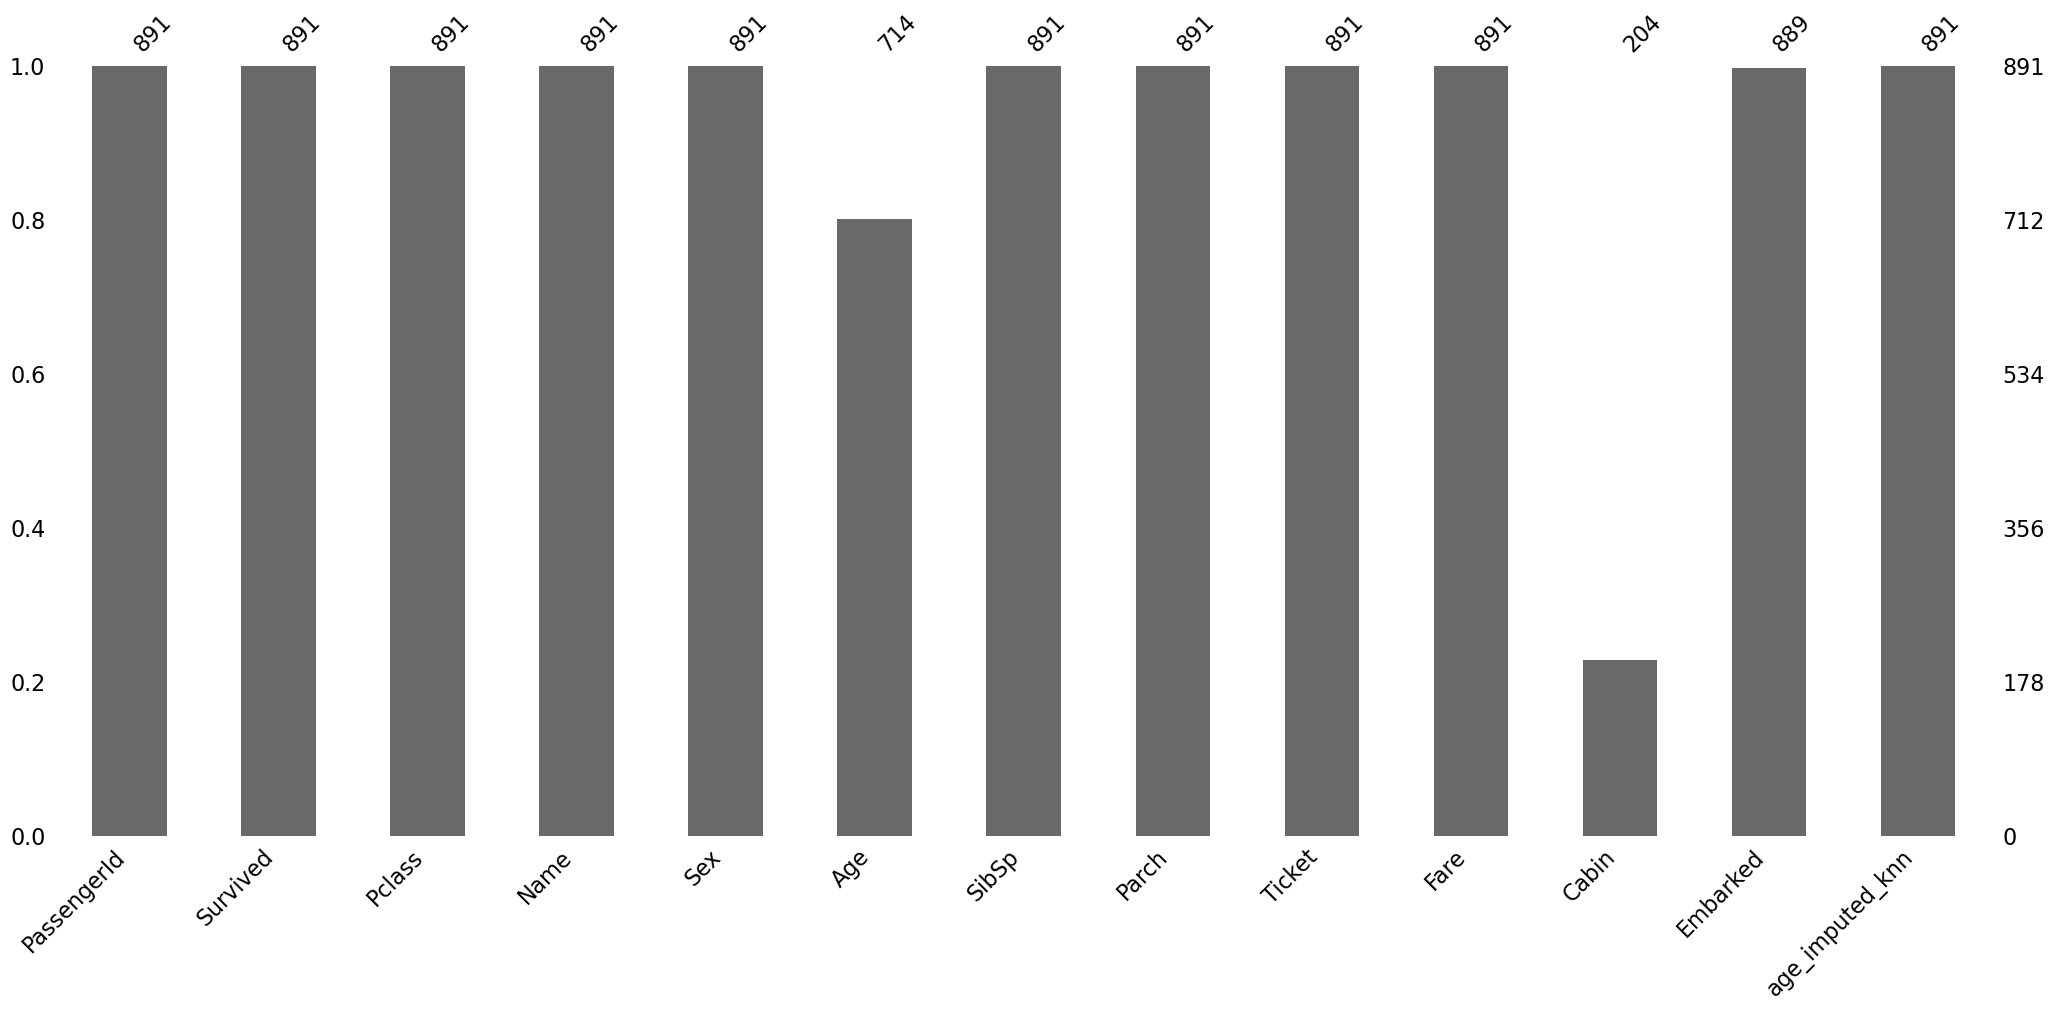

In [141]:
#eksik verinin yapısını inceleyeceğiz. bunun için msno kütüpünü çağırıyoruz.
msno.bar(df)
plt.show()
# ilgili veri setindeki değişknelerin tam sayılarını göstermketedir.

<function matplotlib.pyplot.show(close=None, block=None)>

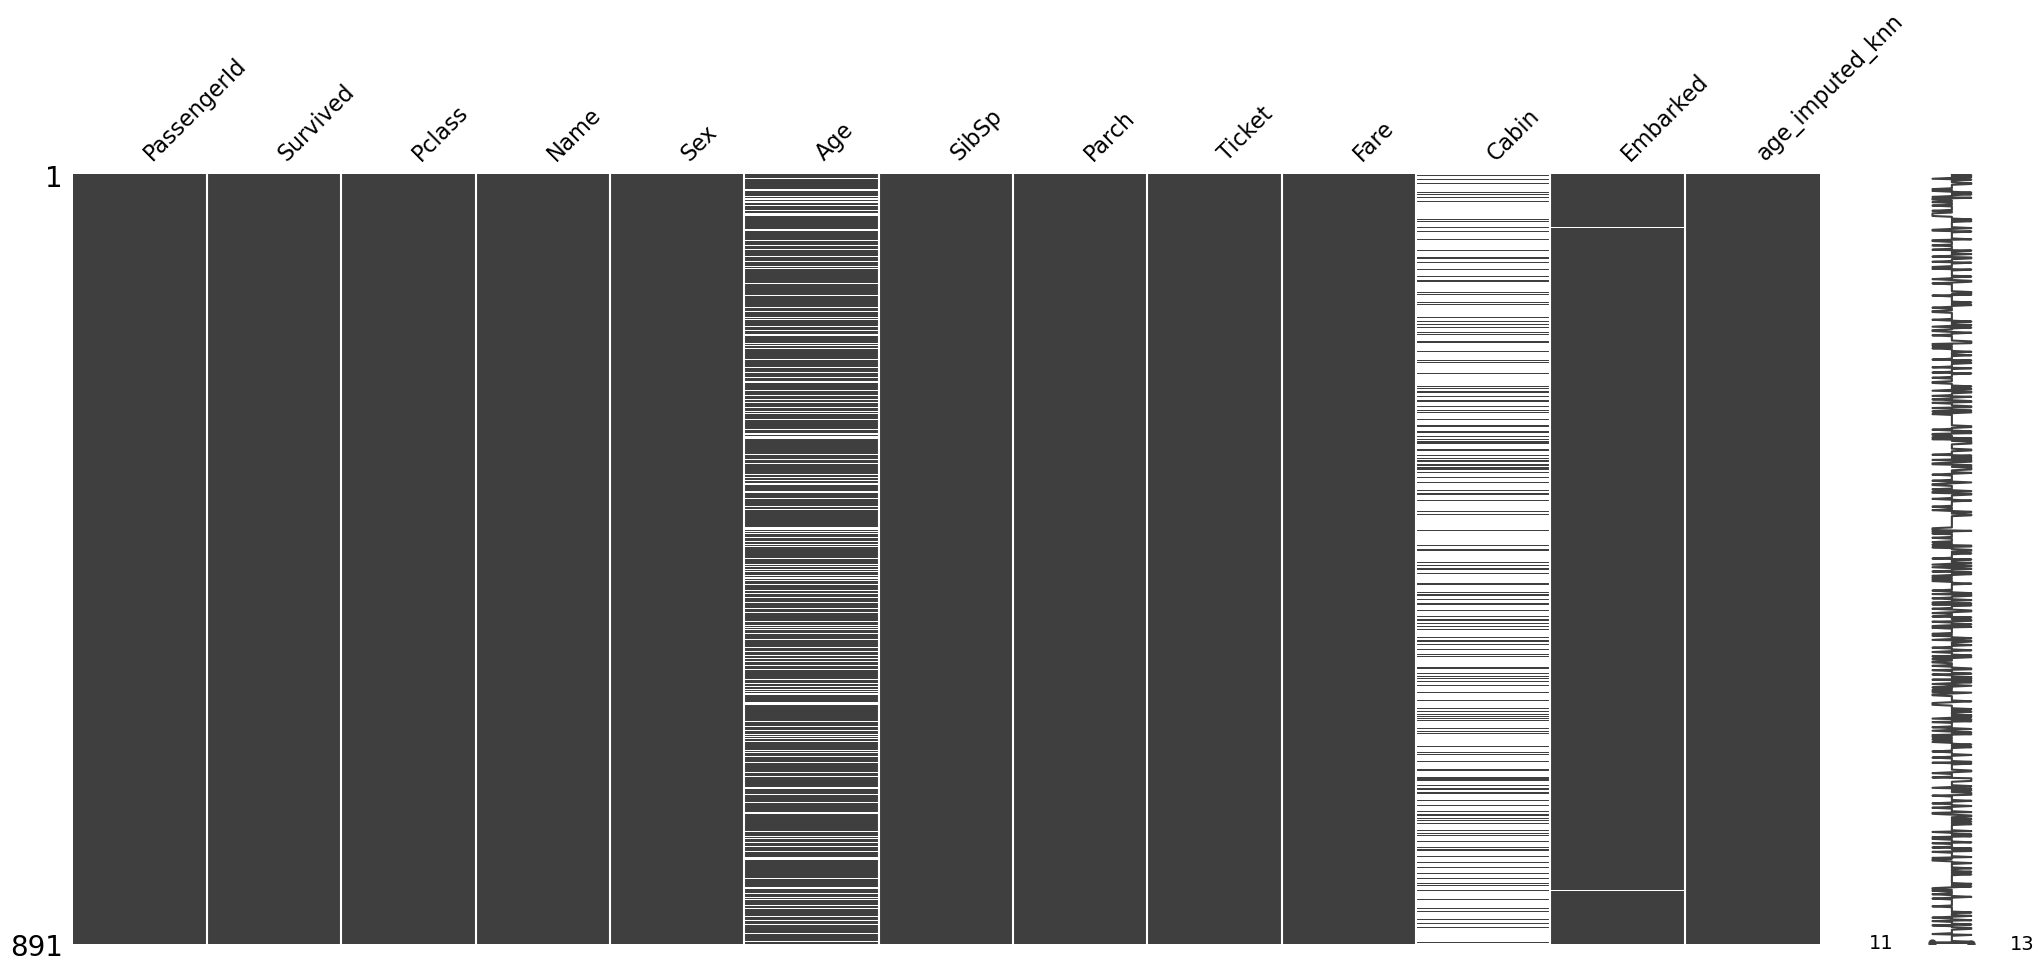

In [142]:
#bir diğer kullanacağımız metod matrix metodudur.

msno.matrix(df)
plt.show
#bu grafik de boş olan verilerin boş olanlarını boş bırakır ve
#eksikliklerin bir arada çıkıp çıkmadığını inceleyen bir araçtır.
#burada eğer değişkendeki eksiklikler birarada meydana geliyorsa 
# örn bir değişkendeki beyazlıklra ile diğer değişkendeki beyazlıklar da benzerse
# ilgili eksiklik beraberdir diyebiliriz. ancak arlarındaki eksikliklerin şu anda 
#çok fazla olduğundan inceleyemedim.

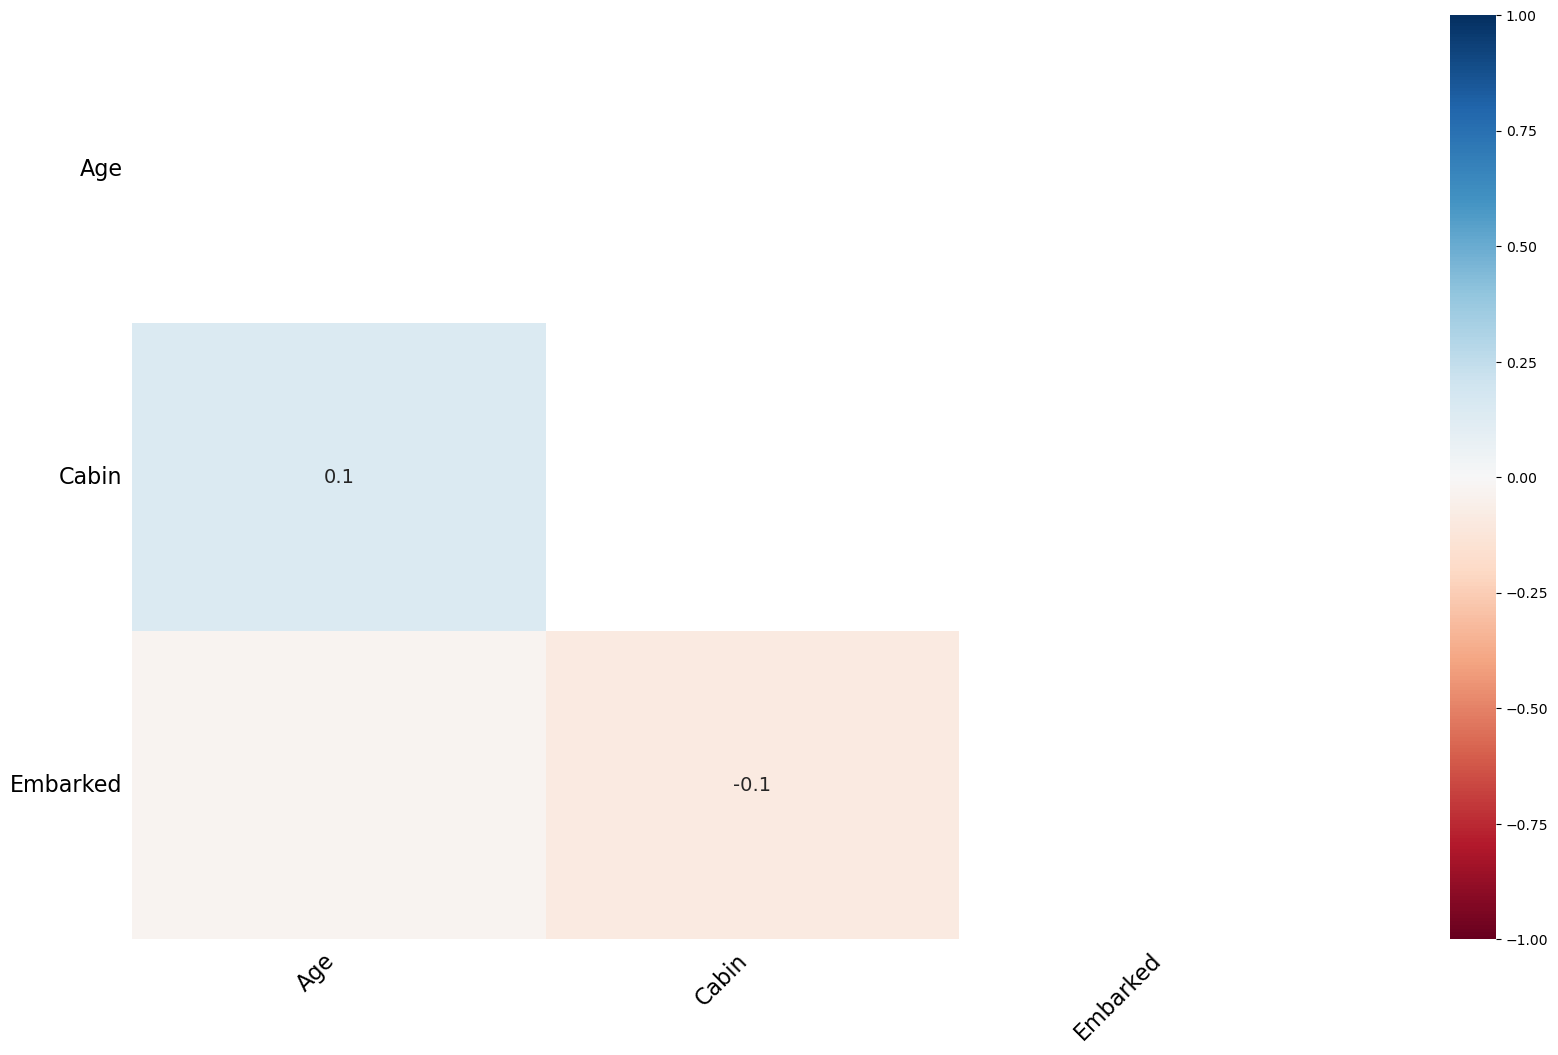

In [143]:
#3.sü headmap, bu eksiklikler üzerine kurulu bir ısı haritası
msno.heatmap(df)
plt.show()

#bu ısı haritasının sunduğu veri çok değerlidir. eksik değerlerin 
# belirli bir korelasyonla çıkıp çıkmadığı durumu ile ilgileniyordul
# yani eksik değerlerin rastsallığı ile ilgileniyorduk, eğer bir değişkende eksiklik varken
#diğer değişkende de eksiklik varsa yani bu eksiklikler acaba birlikte mi oluşuyor gibi bir durumu
# incelemek istiyorduk. fakar dikkat burada iki senaryo var, birincisi eksikliklerin birlikte çıkması senaryosu
# ikincisi eksikliklerin belirli bir ddeğişkene bağlı olarak çıkması senaryosu
# ikside aslında bağımlılık durumudur ancak ikisi arasında küçük bir farklılık var.
# buradaki mapte net bir negatif ya da pozitif korelasyon gözükmemektedir.

 yani burada değişkenlerin arasındaki eksikliklerin arasında eksik olma ile ilgili bir korelasyon yok gibi gözüküyor, şu anda analiz edip anlamaya çalışıyorum.

# EKSİK DEĞERLERİN BAĞIMLI DEĞİŞKEN İLE ANALİZİ

eksik değerlerin bağımlı değişken ile ilişkisinin incelenmesini yapacağız.
amacım şu elimdeki veri setinde bulunan eksik değerlerin bağımlı değişken ile aralarında bir bağlantı var mı bunu araştıracağım.

In [144]:
#missing_values_table(df, True)
na_cols = missing_values_table(df, True)
na_cols #şu anda eksik değere sahip olan tüm değişkenler geldi

          n_miss  ratio
Cabin        687 77.100
Age          177 19.870
Embarked       2  0.220


['Age', 'Cabin', 'Embarked']

In [145]:
def missing_vs_target(dataframe, target, na_columns): #target ilgili veri setindeki bağımlı değişkenim, na_collar var ve df var 
    temp_df = dataframe.copy() #burada dfnin bir kopyası oluşturuluyor istenilirse oluşturulmayabilir.
    for col in na_columns: #naları dışarıdan verdik ve bu nalar içerisinde gez denmiş
        temp_df[col + "_NA_FLAG"] = np.where(temp_df[col].isnull(), 1,0) #temp_df içerisine yeni değişkenler eklemek istiyorum nedir onlar na ya sahip değişkenlerdir. nalara sahip olan değişkene flag ekle denmiş, ilgili değişken eçildikten sonra, bu değişkende eğer bu değişkende eksiklik varsa eksik olana 1 diğerine 0 yaz diyorum. 
        
    na_flags = temp_df.loc[:, temp_df.columns.str.contains("_NA_")].columns #bu temp df de bir seçim yap bütün dataları getir fakat sütunlarda içerisinde na olan sütunları seç ve getir diyorum.
    
    for col in na_flags: # bu değişkenlerde gez ve groupby aldıktan sonra meanini al ve countlarını al ve yazdır.
        print(pd.DataFrame({"TARGET_MEAN": temp_df.groupby(col)[target].mean(),
                           "Count": temp_df.groupby(col)[target].count()}), end="\n\n\n")

In [146]:
missing_vs_target(df, "Survived", na_cols) #survived değişkeni ile bu değişkenleri
#bir karşılaştır diyorum, 3 tane değişkenimin bağımlı değişken olan survived değişkenin
#ortalaması açısından değerlendirmeleri geldi.

             TARGET_MEAN  Count
Age_NA_FLAG                    
0                  0.406    714
1                  0.294    177


               TARGET_MEAN  Count
Cabin_NA_FLAG                    
0                    0.667    204
1                    0.300    687


                  TARGET_MEAN  Count
Embarked_NA_FLAG                    
0                       0.382    889
1                       1.000      2




eksik değere sahip olan yerlere 1 yazdık, dolu olan yerlere 0 yazdık. eksik değere sahip olan gözlemlere odaklanıp survivedın ortalamasını aldığımızda 0.29 çıkmaktadır. tam 177 tane eksiklik varmış. bu satırlarda hayatta kalıp kalamama durumunu ifade eden değişikenin ortalaması 0.29'dur. yani yaş değişkeninde eksiklik olma senaryosunun hayatta kalma oranı 0.29dur, dolu olan kısmın hayatta kalma oranıysa 0,40'tır. arada bir fark var gibi gözüküyor. bundan kuşkulanmam lazım çünkü aralarında fazla fark var. ana amacım burada survived yani hayatta kalıp kalamam durumunu tanımlamaya çalışmak. yani bir modelleme aşamasına geçildiğinde amacım şu olacak insanların bu gemiye bindiğinde hayatta kalıp kalamama durumlarını ortaya çıkaran şey nedir sorusuna yanıt vermeye çalışacağız ve bazı insanların bilgileri verildiğinde hayatta kalıp kalmayacağını tahmin ediyor olacacağız 
dolayısıyla survivedı hayatta kalma durumunu ne etkiliyor sorusuna cevap arıyoruz. dolayısıyla buradan hareketle gözlemlediğimde yaş değişkeninde eksiklik olan senaryonun hayatta kalma oranının daha düşük olduğunu görüyorum. ancak benim için tam olarak yeterli değil başka bir değişkene bakıyorum, cabin_na_flag değişkenine bakıyorum, kabin değişkeninin %75inden fazlası eksikti bu değişken çöp diye düşünüp bu değişkeni atabilirdik ancak cabin değişkeninde na olanların hayatta kalma oranı sadece 0.30 ancak kabin numarası olanların hayatta kalma oranı 0.66dır oranlar arasındaki fark çok yüksek olduğu için sonuç oldukça açıktır. buraya ciddi şekilde odaklanılmaldır. acaba bu neden oluşuyor diyerek soru ortaya atıyorum. yani burada iş bilgisi biliniyor olsaydı neden olduğunu bilebilirdim. büüyk çoğunlu aslında gemi çalışanları olduğu için kabinleri olmadığını bilirdim ve buradan yola çıkarak eksik verilerin de neden oluştuğunu bilmeden silmemem gerektiğine büyük bir örnektir. ben artık cabin değişkeninin ne olduğunu bildiğim için değişkenini oluşturabilirim silmeme gerek yoktur. diğer örneğe bakalım embarkeda bakıyorum, embarked değişkenindeki naları da flagledik ve zaten 2 tane var na olanlara 1 olmayanlara 0 dedim. burada countları atmamın sebebi de o adet bilgisine ulaşarak da yorumlayabilmek istiyorum. bundan sonra kabin değişkenine farklı yaklaşacağım 

# 3 ) ENCODING SCALING

# ENCODING 

1) Label Encoding, 2) One - Hot Encoding, 3) Rare Encoding

encoding ne demek? değişkenlerin temsil şekilleri üzerinde değişiklik yapmak demektir. görecek olunan yöntemlerden ilki
1) label encoding'tir
label ne demek, örn bir kategorik değişkenin sınıfları labellardır. bruadaki labelları yeniden encod etmek yeniden kodlamak demektir. peki bu labelları encod ettiğimizde nasıl bir hale gelmesini bekliyoruz? örn daha öncesinde str ile ifade edilen bu değerleri 0 ve 1'lerle temsil etmek istiyoruz. label encod elimizdeki kategorik değişkenin sınıflarını 0-1 şeklinde ya da 0-1-2-3-4... şeklinde, kullanacak olduğumuz yöntemlerin anlayacağı dile çevirme şekillerinden biridir.

label encod ile elimde bir kategorik değişken varken ve bu kategorik değişken 'ordinal' bir kategorik değişkense, yani sıralı bir kategorik değişkense, yani sınıflar arasında hiyerarşik bir fark varsa bu değişkeni bu şekilde label encod edebilirim, ancak aralarında hiyerarşik bir fark olamayan sınıfları arasında fark olamayan(nominal) labelları değiştiremem. çünkü sayısal olarak değerler üzerindeki etki devam etmemektedir. buradaki sayısal değerler büyüklükleri ifade etmektedir. burada yapılması gereken doğru işlem one hot encoderdan geçmesidir. one hot encoding değişkendeki her bir sınıfı sütun olarak bir değişkene dönüştürecektir.

# LABEL ENCODING 

In [147]:
#label encoding karşımıza binary encoding olarak da gelebilir, eğer bir kategorik değişkenin iki sınıfı varsa
# ve bu 1-0 olarak kodlanırsa buna binary encoding denmektedir. gennel ismi label encodingtir eğer kategori kdeğişkenin ikide fazla labelı varsa binary denmez

df = load()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


In [148]:
#şimdi bunu sex değişkenime uyarlayacağım. yapmak istediğim şey bu değişkeni
#binary encod etmek yani label encod etmek. peki bunu neden yapmak istiyorum, 
#bunu yapmadan makine öğrnmesi yöntemlerini kullanmaya çalışırsam zaten izin vermeyecek çünkü onlar
#matematiksel gösterimlerle çalışan yöntemlerdir. bunun tabi ki istisnaları var ancak genel kullanımda 
#algoritmaların benden beklediği bir veri yapısı var ve buna uygun hareket edebilmek için genelde label ya da onehot encod kullanılır
#tek sebebim bu değildir, bazen yaptığımmız one hot encod işlemlerinde amacımız bir kategorik değişkenin önemli olabilecek sınıfını değişkenleştirerek ona bir değer
#atfetmek olacaktır. bu sayede model performansı gelişebilir.

df["Sex"].head()

0      male
1    female
2    female
3    female
4      male
Name: Sex, dtype: object

In [149]:
#labelencod nesnemi getiriyorum

le = LabelEncoder() #bu nesneyi fit_transform metodunu kullanarak değişkenime uyarlamam lazım

le.fit_transform(df["Sex"])[0:5] #yani önce bu label encoder nesnesini bu değişkene uyarla ondan sonra değerlerini transform ile dönüştür diyorum,
# fit_transform iki basamaklı bir işlemdir ilk basamağında öncelikl dönüştürme işlemi yapılır, daha sonrasonda transform devreye girerek dönüştürme işlemi yapılır
#sonra 0dan 5e kadar gösterdim ve değerlerin dönüştüğünü gördüm

#alfabetik sıraya göre labelencoder ilk gördüğü değere 0 değerini verir diğerine 1 verir

array([1, 0, 0, 0, 1])

In [150]:
# 1in hangi sınıf 0ın hangi sınıf olduğunu öğrenme ihtiyacım olursa bunu inverse_transform metodu ile öğrenebilirim

le.inverse_transform([0, 1]) #le nesnesi içerisindeki dönüştürme bilgileri tutulmaktadır.
#yani lein içinde dönüştürme bilgisi olduğu için inverse_trnasofrm dediğimde ve içerisine 0ın dönüştürme bilgisi neydi diye sorduğumda ya da 1i bana söyleyecektir.
#0ın karşılığı efmale 1in karşılığı maleymiş

array(['female', 'male'], dtype=object)

In [151]:
# bunu kendi ihtiyaçlarıma uygun olabilecek şekilde bir fonksiyon haline getiriyorum

def label_encoder(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe


#bu fonksiyonun argümanlarında ilk df verdik daha sonra dikkat bir binaty col veriyorum yani iki labellı bir kolon olması gerekmektedir.
#label encod çağırma ve fit_transform işlemlerimi aynı şekilde yapıp return ediyorum

In [152]:
df = load()
#veri setimi tekrar okutup deneyeceğim ancak yeni bir problemim var bunu ölçeklenebilir 
# şekilde yapmak istiyorum bunu nasıl yapacağım? bu durumda binary colları seçmem gerekmektedir.
#burada encod etmek için iki seçeneğim var, one hotda kullanabilirim, bruada get_dummies metodunu kullanırız ve kullanırken eğer dropfirstü true yaparsak
#bu durumda iki labellı değişkenler de encoderdan geçirilmiş olur.

# ya da iki sınıflı kategorik değişkenleri seçip label encoderdan geçirebilirim.

In [153]:
#iki sınıflı kategorik değişkenleri seçeceğim

binary_cols = [col for col in df.columns if df[col].dtype not in [int, float]
              and df[col].nunique() == 2]

# sütunlarda gez, gezmiş olduğun sütunların tipine bak, burada int ve float varsa alma
#ve aldıkların sütunların nuniq değeri 2ye eşitse al, int sınıfın zaten iki sınıfı varsa bununla ilgilenmiyorum zaten binary edilmiş oluyor o
#dolayısıyla int ve float olmayan nuniq değeri 2 olan değişkenleri al diyorum.
binary_cols

['Survived', 'Sex']

In [154]:
binary_cols = [col for col in binary_cols if col != "Survived"]

binary_cols #onda sadece sex olduğu için survivedı çıkardık.

['Sex']

In [155]:
#burada unique yazıp neden len metpduyla hesaplamadım gibi bir soru gelirse 
#burada unique metodu değişkendeki eksik değeleri de sınıf olarak görüp sayar bu yüzden
#yanlışlığa sebep olabilir buna dikkat etmek lazım. bu yüzden nunique kullandık

In [156]:
#örn elimdeki binary col sayısı 10 civarı olsaydı ne yapacaktım
# kolonlarda gez ve label_encoderı çalıştır diyecektim

for col in binary_cols:
    label_encoder(df, col) #yukarıda kalıcı değişiklik yaptığım için yeniden atama işlemi yapmama gerek yok

In [157]:
df.head() #gözlemliyorum

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.000,0,0,373450,8.050,NaN,S


büyük olan veri setiyle de aynı işlemi yapıyor. label encod edilecek  aynı kodlar kullanılarak

buradaki naların farkında olmam lazım ona göre nunique ya da len(unique) yapmam lazım

# ONE HOT ENCODING

bir önceki dersteki label encodingteki problem sınıflar arasında fark olmamasına rağmen fark varmış muamelesi yapmış olmamdı, bunu bu şekilde yapmam doğru olmayacaktı bunun etkisi de doğrusal yöntemlerde kendini ciddi şekiled hissettirecektir diyebilirim. bunları nasıl daha doğru şekilde temsil edebilirim diyorum. bunu yapmanın doğru yolu one hot encoding diyorum. yani kategorik değişkenimdeki sınıfları ayrı ayrı değişkenlere dönüştürüyorum. her birini sütunlara getirip sınıfıyla çakıştığı yere 1 diğerlerine 0 koyuyuorum. yalnız burada bir dummies değişken tuzağı mevcut. 
one hot encod kullanırken kullanacağımız metodlarda drop ifrst diyerek ilk sınıfı drop etmiş olarak ortaya çıkabilecek olan dummies değişken tuzağından kurtuluruz. dummy değişken tuzağı, kukla değiken tuzağı ne demek? burada oluşturmuş olduğumuz değişkenlere dummy değşken denir, bu kula değişkenler eğer birbiri üzerinden oluşturulabilir olursa bu durumda ortaya bir ölçme problemi çıkar, yani biribiri üzerinden oluşturulan değişkenler biribiri ile yüksek korelasyona sebep olacaktır. bundan dolayı dummy değişken oluşturulurken ilk sınıf drop edilir ve birbiri üzerinden oluşturulma durumu ortadan kaldırılmaya çalışılır.

# ONE HOT ENCODING 2

In [158]:
df = load()
df.head()
df["Embarked"].value_counts()

#burada embarked kategorik değişkeni var ve 3 sınıfı var, bu sınıflar arasında bir
#fark yok, eşit aralık var, nominal ölçek tüüryle ölçülmüş yani s-c-q sınıflları arasında
#hiyerarşik bir sınıf yok. dolayısıyla bunu label encodaa sokmak problem çıkaracağından dolayı
# sınıfları arasında normalde fark yokken varmış gibi gözükeceğinden dolayı, one hot encoddan geçirebiliriz.
# bunun için pandasın get_dummies metpdu kullanılır

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [159]:
#pd.get_dummies(df, columns=["Embarked"]).head() #bu metod der ki, bana bir dataframe söyle, bu df içinde dönüştürmek istediğin
#sütunların adını söyle, ben sadece onları dönüştüreceğim diğerleri olduğu giib kalacak diyor. embarkedı dnüştürüp gözlemliyorum
#embarkedın 3 sınıfı için dönüşüm gözlemlendi

In [160]:
#öncelikle burada dummy değişken tuzağına düşmemek için dropfirst argümanını true yapacağız
pd.get_dummies(df, columns=["Embarked"], drop_first=True).head() 
# tekrar gözlemliyorum ve bakıyorum ki ilk sınıfım artık yok, ilk sınıfı neye göre seçiyor peki dersem alfabetik sıraya göre seçiyor diyebilirim

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,0,1


In [161]:
#ikinci önemli nokta olarak eğer ben eksik değerler de bir sınıf olarak gelsin istersem
#eksik değerler parametremi de True yapmam gerekmektedir.

pd.get_dummies(df, columns=["Embarked"], dummy_na=True).head()

#gözlemlendiği gibi artık burada eksik değerlerim de bir sınıf olarak gelmektedir.
#bu özellik her zaman terih edilmeyebilir.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,0,0,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,1,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,0,0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,0,0,1,0


In [162]:
#burada hem label hem de one hot encoding işlemini aynı anda yapamaz mıyım diye bir sor soruyorum
#yapabilirim, ancak burada label encodda sadece binary encod olanları aynı anda one hota sokarak encod edebilirim
# nasıl olacak? burada zaten binary 2 adet sınıf içerdiği için encod edilirken yine 1 ve 0 olarak ayrılacağından dolayı
# enco edilmiş olacak, gözlemleyelim,

pd.get_dummies(df, columns=["Sex","Embarked"], drop_first=True).head() 

#burada görüldüğü gibi sex sütunu one hot encoda sokularak binary encdoing uygulanmış oldu bu şekilde aynı anda kullanılabilir
#eğer bir kategorik değişkenin iki sınıfı varsa dropfirst dediğimde o değişken otomatik olarak binary encod edilmiş oluyor

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.000,1,0,A/5 21171,7.250,NaN,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.000,1,0,PC 17599,71.283,C85,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.000,0,0,STON/O2. 3101282,7.925,NaN,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.000,1,0,113803,53.100,C123,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.000,0,0,373450,8.050,NaN,1,0,1


In [163]:
#şimdi de kendi fonksiyonumu yazıyorum, ne yapacak bu fonksiyon,get_dummiesi çağıracak ve kategorik değişkenlere ilgili işlemi gerçekleştireck
# buradaki dropfirstü kendi isteğimize göre true bırakabiliriz.

def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns = categorical_cols, drop_first=drop_first)
    return dataframe

In [164]:
df = load()

cat_cols, num_cols, cat_but_car = grab_col_names(df) #bize kategorik değişkenleri versin

Observations: 891
Variables: 12
cat_cols: 9
num_cols: 3
cat_but_cardi: 3
num_but_cat: 4


In [165]:
cat_cols #burada iki yaklaşım uygulanabilir,tüm kategorik değişkenlere ona hot uygulanabilir,
#ya da seçecek olduğumuz bazılarına uygulayabiliriz ya da yine programatik olarak numer uniq sayısı en azından
#3ten büyük olanlara uygulayalım diyebiliriz.

# burada lsite dışında bırakmak istediklerim olabilir örn burada survived değişkenini
#dışarıda bırakmak istiyorum ve burada pclass örn normalde sayısal bir değişken ve hatta ordinal 
# bir değişken normalde olduğu gibi kalabilir ancak one hottan da geçirilebilir çünkü aslında kategorik değişken,
#buradaki sibsp ve parch da akrabalık ilişkilerini ifade ediyordu, burada hepsini encoddan geçirebilirim, diye yorum yapabilirim,
#anca survivedı dışarıda bırakmak istiyorum.

# diğer yorum şu olabilir daha öncesinden cinsiyeti değiştirdiğimizi varsayarsak, mesela burada survived iki sınıflı ama bu benim bağımlı değişkenim,
# bunu da istemiyorumu varsayarsak, burada one hot encoderdan geçecek sütunşarı özenle seçip kendim takip edebilirim.
#genelde kendi tercihimiz bu şekilde olmalı

['Name',
 'Sex',
 'Ticket',
 'Cabin',
 'Embarked',
 'Survived',
 'Pclass',
 'SibSp',
 'Parch']

In [166]:
#o yüzden kontrollü gideceğim. ohe kolsla diyorum ki ilgili df sütunlarında gez
#eğer değişkenin nuniq sayısı 2den büyükse ve ondan küçükse bu durumda bunları seç

ohe_cols = [col for col in df.columns if 10 >= df[col].nunique() > 2]
ohe_cols

# burada kimlerden kurtuldum, cinsiyetten ve surviveddan kurtuldum, yani istemediklerimden
# kurtuldum. bu sefer programatik olarak yapma şeklimi bu şekilde istedim. burada 10 yorumdur duruma göre değişebilir.
#bu ohe_colsları one hot encoderdan geçirelim.

['Pclass', 'SibSp', 'Parch', 'Embarked']

In [167]:
one_hot_encoder(df, ohe_cols).head() #dropfirstü en son true bırakmıştık, kalıcı değişiklik istersem burada dfye atamam gerekir.

,PassengerId,Survived,Name,Sex,Age,Ticket,Fare,Cabin,Pclass_2,Pclass_3,SibSp_1,SibSp_2,SibSp_3,SibSp_4,SibSp_5,SibSp_8,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Embarked_Q,Embarked_S
0,1,0,"Braund, Mr. Owen Harris",male,22.000,A/5 21171,7.250,NaN,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,PC 17599,71.283,C85,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,1,"Heikkinen, Miss. Laina",female,26.000,STON/O2. 3101282,7.925,NaN,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,113803,53.100,C123,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
4,5,0,"Allen, Mr. William Henry",male,35.000,373450,8.050,NaN,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1


# RARE ENCODING 

Rare nadir demektir. az gözlemlenen demektir. diyelim ki elimde bir gözlem var ve bu gözlemin gözlem frekansları verilmiş, yani countları verilmiş. burada birçok yüksek değer varken bazı düşük değerler de gözlemlenmiştir. burada bu düşük değerleri ne yapacağım problemi bulunmakta. burada karmaşıklık yerine basitlikten gitmemiz gerektiği için, gözlemlenen değerlerin çoğunluğunu kapsayan değerleri ele almam gerekmektedir. bir model kuracağız ve bu modeli çeşitli sistemlere entegre ediyor olacağız diyebiliriz. örn ev fiyat tahmini, araç fiyat tahmini gibi bir problemi çözecek olan bir makine öğrenmesi problemi olsun, şimdi benim yüzbinlerce kaydın içinde iki defa gözlemlenmiş bu değer bunu one hot encoderdan geçirilince bir değişkene dönüşüyor olacak ve bu değişkenin sadece 2 tane hücresinde 1 diğer kalan tüm hücrelerinde 0 yazacak. bu yüzden bu sütunlar bir değer taşıyor ya da bilgi taşıyor diyemeyiz. yani çok az sayıda gözleme sahip olduğu için kurduğum modele bu değişkenlerden bir değer gelme ihtimali çok çok çok düşük olduğundan dolayı ve bunun gibi oluşan sınıflardan dolayı karşılık bulma ihtimalleri çok düşük. bağımlı değişkene göre ayırt edicilik sağlayığ sağlamadığı bir bilgi taşıdığı durumu da tartışılabilir durumdadır. hatta bu değikenler çok az olduğu için rastgele bile gelmiş olabilir diyorum. bilemediğim için. dolayısıyla bu değişkenleri one hottan geçirirken bir ölçüm kalitesi olsun istiyorum. bağımlı değişkene çeşitli etkilerinin olmasını istiyorum ve gereksiz değişkenlerin oluşmasını istemiyorum. gereksiz değişkenler iterasyon, optimizasyon süresini ve ağaç yöntemlerindeki bölünme, dallanma süreçlerini çok ciddi etkiliyor olacaktır. bu durumd rare encod kullanılabilir. tüm süreçlerde yapılmasına gerek yoktur eğer istenirse kullanılabilir. fayda sağlayan bir metoddur ancak dikkat edilmelidir. risklidir. nasıl çalışır, bir eşik değer belirlenir örn 25in altınd olan gözlem değerlerini istemiyorum. bu değerlerimi seçiyorum ve sonra bu değerlerimin hepsini tek labelda bir araya getiriyorum ve normal bir değişkenmiş gibi ele alıyorum. veri setindeki kategorik değişkenin belirli bir eşik değere göre nadir gözlemlenen değerlerini ve muhtemelen tek başına ele alınsa bilgi taşımayacak sınıflarını birleştirip bir değişken gibi ele almama rare encoding denir. 

# RARE ENCODING 2

rare biraz daha orta ileri seviye işlemdir. büyük veri setlerine hayat kurtarır

bu bölümde :
1. kategorik değişkenlerin azlık çokluk durumunun analiz edilmesi
2. rare kategoriler ile bağımlı değişken arasındaki ilişkinin analiz edilmesi
3. rare encoder yazacağız

In [168]:
def load_application_revi():
    df = pd.read_csv("application_train.csv")
    return df

In [169]:
df = load_application_revi()

df["NAME_EDUCATION_TYPE"].value_counts()
# frekansları az olanları ayıklamam gerekmektedir. az olanları bir araya getirmeye çalışacağım
# problemim buradaki kategorik değişkenleri seçmek ancak nasıl seçeceğim

Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: NAME_EDUCATION_TYPE, dtype: int64

In [170]:
#head atıp ön inceleme
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000,406597.500,24700.500,351000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.019,-9461,-637,-3648.000,-2120,NaN,1,1,0,1,1,0,Laborers,1.000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083,0.263,0.139,0.025,0.037,0.972,0.619,0.014,0.000,0.069,0.083,0.125,0.037,0.020,0.019,0.000,0.000,0.025,0.038,0.972,0.634,0.014,0.000,0.069,0.083,0.125,0.038,0.022,0.020,0.000,0.000,0.025,0.037,0.972,0.624,0.014,0.000,0.069,0.083,0.125,0.037,0.021,0.019,0.000,0.000,reg oper account,block of flats,0.015,"Stone, brick",No,2.000,2.000,2.000,2.000,-1134.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000
1,100003,0,Cash loans,F,N,N,0,270000.000,1293502.500,35698.500,1129500.000,Family,State servant,Higher education,Married,House / apartment,0.004,-16765,-1188,-1186.000,-291,NaN,1,1,0,1,1,0,Core staff,2.000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311,0.622,NaN,0.096,0.053,0.985,0.796,0.060,0.080,0.035,0.292,0.333,0.013,0.077,0.055,0.004,0.010,0.092,0.054,0.985,0.804,0.050,0.081,0.035,0.292,0.333,0.013,0.079,0.055,0.000,0.000,0.097,0.053,0.985,0.799,0.061,0.080,0.035,0.292,0.333,0.013,0.079,0.056,0.004,0.010,reg oper account,block of flats,0.071,Block,No,1.000,0.000,1.000,0.000,-828.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
2,100004,0,Revolving loans,M,Y,Y,0,67500.000,135000.000,6750.000,135000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010,-19046,-225,-4260.000,-2531,26.000,1,1,1,1,1,0,Laborers,1.000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.556,0.730,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [171]:
# artık biliyorum nasıl seçmem gerektiğini grab col ile kategori kdeğişkenlerimi ayıklıyorum
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 307511
Variables: 122
cat_cols: 55
num_cols: 67
cat_but_cardi: 1
num_but_cat: 39


In [172]:
cat_cols # kategorik değişkenlerim geldi

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE',
 'TARGET',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'DEF_60_CNT_SOCIAL_CIRCLE',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_6',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_13',
 'FLAG_DOCUMENT_14',
 'FLAG_DO

In [173]:
# burada yeni bir fonksiyona ihtiyacım var, bu kategorik değişken öyle bir iş yapmalı ki bu aktegorikk 
#değişkenin sınıflarının oranlarını getirmeli

def cat_summary(dataframe, col_name,plot=False): # plot argümanı var bunu şimdilik fasle yapıyorum
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                       "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("################################")
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show()

In [174]:
for col in cat_cols: #cat_cols üzerind egezip cat_Summaryi uyguluyorum
    cat_summary(df, col)

                 NAME_CONTRACT_TYPE  Ratio
Cash loans                   278232 90.479
Revolving loans               29279  9.521
################################
     CODE_GENDER  Ratio
F         202448 65.834
M         105059 34.164
XNA            4  0.001
################################
   FLAG_OWN_CAR  Ratio
N        202924 65.989
Y        104587 34.011
################################
   FLAG_OWN_REALTY  Ratio
Y           213312 69.367
N            94199 30.633
################################
                 NAME_TYPE_SUITE  Ratio
Unaccompanied             248526 80.819
Family                     40149 13.056
Spouse, partner            11370  3.697
Children                    3267  1.062
Other_B                     1770  0.576
Other_A                      866  0.282
Group of people              271  0.088
################################
                      NAME_INCOME_TYPE  Ratio
Working                         158774 51.632
Commercial associate             71617 23.289
Pensi

   FLAG_DOCUMENT_5  Ratio
0           302863 98.489
1             4648  1.511
################################
   FLAG_DOCUMENT_6  Ratio
0           280433 91.194
1            27078  8.806
################################
   FLAG_DOCUMENT_7  Ratio
0           307452 99.981
1               59  0.019
################################
   FLAG_DOCUMENT_8  Ratio
0           282487 91.862
1            25024  8.138
################################
   FLAG_DOCUMENT_9  Ratio
0           306313 99.610
1             1198  0.390
################################
   FLAG_DOCUMENT_10  Ratio
0            307504 99.998
1                 7  0.002
################################
   FLAG_DOCUMENT_11  Ratio
0            306308 99.609
1              1203  0.391
################################
   FLAG_DOCUMENT_12  Ratio
0            307509 99.999
1                 2  0.001
################################
   FLAG_DOCUMENT_13  Ratio
0            306427 99.647
1              1084  0.353
######################

In [175]:
# code_gender diye bir sınıf var ve burada xna sınıfı var, mesela bu değişken
# çöp bir bilgi taşımamakta çünkü 0.001 yüzdelik diliminde yer almakta. direkt olarak silinmesi gereken bir değişken
#bir değişkene dönüştüğünde kullanılmaması gereken bir değişkendir. bu durum diğer değişkenlerimde de mevcut
#bunları rare encoddan geçirmem gerekmektedir. bazı filtreleme işlemleri yapmam gerekmektedir.
#burada target ev kredisi ödeyememe durumunu temsil etmektedir, 1.sınıf ödeyememe durumunu temsil eder ya da 
#ödeyememe davranışı sergiliyor geciktirdi gibi., 0 ise ödeyememe alışkanlığı yok demek.
# bu veride rare yapılması gereken değişkenler mevcut, one hot yapılmadan önce. tüm yüzdelikler verinin tamamına göre hesaplanıyor.


In [176]:
# şimdi de 2. aşamaya geçiyorum. 
#2.rare kategoriler ile bağımlı değişken arasındaki ilişkinin analiz edilmesi
df["NAME_INCOME_TYPE"].value_counts()#bu değişkeni target ile groupbya alıp ortalamasın bir bakmak istiyorum ki değişken ile arasındaki ilişkiyi göreyim.

Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: NAME_INCOME_TYPE, dtype: int64

In [177]:
df.groupby("NAME_INCOME_TYPE")["TARGET"].mean()
#businessman ortalaması 0 bu ne demek ,1 e yakın olması durumunda krediyi ödeyememeyi ifade etmektedir
# 1den uzak 0a yakın olması krediyi ödeyebilmeyi ifade etmektedir, businessmanlerin krediyi ödeyebilmeme durumları
#krediyi ödemeye yakın gibi gözüküyor, öğrenciler 0 a yakın, işsizlerin ödeyememeye daha yakın oluğu
#temrrüt yani geciktirme 1 e daha yakın olduğu gözlemlenmektedir. tek başına buradan karar alınabilir mi 
#kişiye kalmış. mesea burada buesiness manle unemployed başta birleştireilebilir gibi gözüküyordu ancak 
#target açısından birleştiremeyeceğimi gördüm, buralar yoruma açık şekilde duruyor.
# burada birbirinden farklı sınıflar birleştirilip iyi yönde etkileyeceği varsayımı üzerinden gidilebilir,
# ancak farklı sınıfları birleştirdim acaba gürültü mü ekliyorum diye de düşünülebilir. burada 
# yöntem gösterilir detaylı gidiş veriye göre kararlarıma göre olmalıdır.

NAME_INCOME_TYPE
Businessman            0.000
Commercial associate   0.075
Maternity leave        0.400
Pensioner              0.054
State servant          0.058
Student                0.000
Unemployed             0.364
Working                0.096
Name: TARGET, dtype: float64

In [178]:
# daha önce yaptığım işlemleri bir araya getirecek bir fonksiyon tanımlıyorum

def rare_analyser(dataframe, target, cat_cols):
    for col in cat_cols:
        print(col, ":", len(dataframe[col].value_counts()))
        print(pd.DataFrame({"COUNT": dataframe[col].value_counts(),
                           "RATIO": dataframe[col].value_counts() / len(dataframe),
                           "TARGET_MEAN": dataframe.groupby(col)[target].mean()}), end="\n\n\n")

In [179]:
#bağımlı değişkenimi ve kategorik değişkenlerimi verdiğimde yukarıdaki işlemleri bana yapmasını sağlayacağım
#1. bölüme ilgili kategorik değişkenin kaç sınıfı var bilgisi, sonra sınıf frekansları, sınıf oranları ve bağımlı değişkene göre groupby işlemi

rare_analyser(df, "TARGET", cat_cols)
#elimdeki tüm kategorik değişkenler için rare analizini gerçekleştirdim

NAME_CONTRACT_TYPE : 2
                  COUNT  RATIO  TARGET_MEAN
Cash loans       278232  0.905        0.083
Revolving loans   29279  0.095        0.055


CODE_GENDER : 3
      COUNT  RATIO  TARGET_MEAN
F    202448  0.658        0.070
M    105059  0.342        0.101
XNA       4  0.000        0.000


FLAG_OWN_CAR : 2
    COUNT  RATIO  TARGET_MEAN
N  202924  0.660        0.085
Y  104587  0.340        0.072


FLAG_OWN_REALTY : 2
    COUNT  RATIO  TARGET_MEAN
N   94199  0.306        0.083
Y  213312  0.694        0.080


NAME_TYPE_SUITE : 7
                  COUNT  RATIO  TARGET_MEAN
Children           3267  0.011        0.074
Family            40149  0.131        0.075
Group of people     271  0.001        0.085
Other_A             866  0.003        0.088
Other_B            1770  0.006        0.098
Spouse, partner   11370  0.037        0.079
Unaccompanied    248526  0.808        0.082


NAME_INCOME_TYPE : 8
                       COUNT  RATIO  TARGET_MEAN
Businessman               10  0.

    COUNT  RATIO  TARGET_MEAN
1   32197  0.105        0.048
2  226984  0.738        0.079
3   48330  0.157        0.111


REGION_RATING_CLIENT_W_CITY : 3
    COUNT  RATIO  TARGET_MEAN
1   34167  0.111        0.048
2  229484  0.746        0.079
3   43860  0.143        0.114


REG_REGION_NOT_LIVE_REGION : 2
    COUNT  RATIO  TARGET_MEAN
0  302854  0.985        0.081
1    4657  0.015        0.093


REG_REGION_NOT_WORK_REGION : 2
    COUNT  RATIO  TARGET_MEAN
0  291899  0.949        0.080
1   15612  0.051        0.089


LIVE_REGION_NOT_WORK_REGION : 2
    COUNT  RATIO  TARGET_MEAN
0  295008  0.959        0.081
1   12503  0.041        0.084


REG_CITY_NOT_LIVE_CITY : 2
    COUNT  RATIO  TARGET_MEAN
0  283472  0.922        0.077
1   24039  0.078        0.122


REG_CITY_NOT_WORK_CITY : 2
    COUNT  RATIO  TARGET_MEAN
0  236644  0.770        0.073
1   70867  0.230        0.106


LIVE_CITY_NOT_WORK_CITY : 2
    COUNT  RATIO  TARGET_MEAN
0  252296  0.820        0.077
1   55215  0.180        0.10

In [180]:
# burada birleştirebileceğim sınıflara karar vermeye çalışıyorum, burada biz 
#uygulamamız kapsamında %1in altında olanları birleştirmeye karar vereceğim. ancak bu bir yorumdur değişebilir.
#elimde kategorik değişkeni fazla olan bir veri seti olduğunda rare analyser fonksiyonumu kullanmam gerekmektdir.
#hangi kategorik değişkenin sınıfı, hagi frekansa, hangi orana ve bağımlı değişken açısından nasıl bir etkiye sahip,
# bunu mutlaka bilmem gerekmektedir.

# RARE ENCODING FONKSIYONU

burada rare encodun fonksiyonunu yazacağız, analizlerimizi yaptık artık işlemleri yapabilirim.

In [181]:
def rare_encoder(dataframe, rare_perc):
    temp_df = dataframe.copy() #üzerinde değişklik yapılacağından copysi alınmış
    
    rare_columns = [col for col in temp_df.columns if temp_df[col].dtypes == "object" #eğer fonksiyona girilen rare oranından daha düşük değişkenin sınıf oranı varsa ve bu aynı zamanda bir kategorik değişkense bunlar rare kolonlar olarak getir  
                   and (temp_df[col].value_counts() / len(temp_df) < rare_perc).any(axis=None)]
    
    for var in rare_columns: #bruada öyle rare barındıran değişkenleri seçmek istiyorum
        tmp = temp_df[var].value_counts() / len(temp_df) #rare barındıran değişkenlerin value_countu alınıp toplam gözlem sayısına bölünerek temp değişken içindeki rare sınıf oranları hesaplanmış
        rare_labels = tmp[tmp < rare_perc].index #daha sonrasında rare _labels adında bir sınıf oluşturulmuş ve veri setiin başında verilen rare oranından daha düşük olan rare oranlarını indirge ki yanni bu sınıflara sahip olan değişkenleri indirgedikten sonra bu indexleri tut  
        temp_df[var] = np.where(temp_df[var].isin(rare_labels), "Rare", temp_df[var]) #gezilen rare kolonlarda rare_labelslardan birini görürsen bunların yerine Rare yaz diyorum 
        #değilse olduğu gibi kalsın
    return temp_df

In [182]:
new_df = rare_encoder(df, 0.01) #dfyi girip 0.01 rare oranımı girdim bu oranıın altında kalan kategorik değişken sınıflarını bir araya getirecek
new_df #bu şekilde 0.01 diyerek dfnin tüm değişkenlerini ve sınıflarını rare encoderdan geçirdim ve bu eşik değer göre rare sınıflarımı yarattım

In [183]:
rare_analyser(new_df, "TARGET", cat_cols) #burada da gözlemledim, eşik değerimi kendim işime göre ayarlamalıyım.

NAME_CONTRACT_TYPE : 2
                  COUNT  RATIO  TARGET_MEAN
Cash loans       278232  0.905        0.083
Revolving loans   29279  0.095        0.055


CODE_GENDER : 3
       COUNT  RATIO  TARGET_MEAN
F     202448  0.658        0.070
M     105059  0.342        0.101
Rare       4  0.000        0.000


FLAG_OWN_CAR : 2
    COUNT  RATIO  TARGET_MEAN
N  202924  0.660        0.085
Y  104587  0.340        0.072


FLAG_OWN_REALTY : 2
    COUNT  RATIO  TARGET_MEAN
N   94199  0.306        0.083
Y  213312  0.694        0.080


NAME_TYPE_SUITE : 5
                  COUNT  RATIO  TARGET_MEAN
Children           3267  0.011        0.074
Family            40149  0.131        0.075
Rare               2907  0.009        0.094
Spouse, partner   11370  0.037        0.079
Unaccompanied    248526  0.808        0.082


NAME_INCOME_TYPE : 5
                       COUNT  RATIO  TARGET_MEAN
Commercial associate   71617  0.233        0.075
Pensioner              55362  0.180        0.054
Rare              

AMT_REQ_CREDIT_BUREAU_HOUR : 5
        COUNT  RATIO  TARGET_MEAN
0.000  264366  0.860        0.077
1.000    1560  0.005        0.080
2.000      56  0.000        0.107
3.000       9  0.000        0.000
4.000       1  0.000        0.000


AMT_REQ_CREDIT_BUREAU_DAY : 9
        COUNT  RATIO  TARGET_MEAN
0.000  264503  0.860        0.077
1.000    1292  0.004        0.097
2.000     106  0.000        0.104
3.000      45  0.000        0.044
4.000      26  0.000        0.115
5.000       9  0.000        0.000
6.000       8  0.000        0.000
8.000       1  0.000        0.000
9.000       2  0.000        0.000


AMT_REQ_CREDIT_BUREAU_WEEK : 9
        COUNT  RATIO  TARGET_MEAN
0.000  257456  0.837        0.077
1.000    8208  0.027        0.078
2.000     199  0.001        0.101
3.000      58  0.000        0.069
4.000      34  0.000        0.118
5.000      10  0.000        0.100
6.000      20  0.000        0.050
7.000       2  0.000        0.000
8.000       5  0.000        0.000




In [184]:
# burada bazı değişkenlerin sınıfları rare ile bir araya getirildi yüzlerce değişkenin sınıfları.

# ÖZELLİK ÖLÇEKLENDİRME (Feature Scaling)

değişken ölçeklendirme ne demektir? değişkenler arasındaki ölçüm farklılığını gidermektir. kullanılacak olan modellere değişkenlerin eşit şartlar altında yaklaşmasını sağlamaya çalışmaktır. örnek vermek gerekirse elimde 3 farklı değişken var ve birincisi filmlere verilen puan sayısı, ikincisi yorum sayısı diğeri de 1 ile 10 arasında filmlere verilen puan sayısı. dağılımları farklı olduğu için aynı etki açısından bir modellemeye sokamıyorum ancak ağaç yöntemleri buna istisnadır. hatta göz ardı edilebilmektedir. ancak en genel manada machine learning algoritmalarında bu tarz değişiklikler kullanılan algoritmalarda yanlılıklara sebep olmaktadır. dolayısıyla bu 3 değişken scale edilir yani ölçeklendirilir. 1. maddemiz tüm değişkenleri eşit şartlar altında değerlendirebilmek adına ölçeklendirmektir. neden, örn değişkenlerim numeric değişkenlerden oluşmaktadır ve biri diğerinden daha büyük değerlere sahip olunca sistem bozuluyor. saedce büyük ya da küçük olarak algılayabilir, önemli olan kendi içlerindeki büyüklük ve küçüklük dağılımları korunuyor olmalıdır ve birbirileri arasındaki ölçeklendirme problemi çözülmelidir. ikinci önemli maddemiz özellikle gradient distance kullanan algoritmaların train sürelerini kısaltma durumudur. dikkaat scale edilmiş featurelar söz konusu olduğunda bu ölçeklenmiş featureların üretecekleri errorların boyutları ve bunların iteratif olarak azaltılması çabası değişkenler standart olduğunda daha hızlı olmaktadır. dolayısıyla ölçekleri birbirinden farklı olması durumunda bu değişkenler üzerinden minimum noktaya erişecek şekilde gradient distance yöntemini kullandığımızda scale edilmemiş featureların süresi daha uzun sürmektedir. çünkü her iterasyonda kaynaklanan errorların boyutları büyük olacağından dolayı daha uzun sürede minimum noktaya erişiliyor olacaktır. 3. madde olarak da uzaklık temelli yöntemlerde büyükdeğerlere sahip değişkenler dominantlık sergilerler, bu da aslınd a1. maddeyle aynı anlama sahip, özellile knn, k-means, pca gibi yada benzerlik, benzemezlik temelli bazı yöntemler kullanılıyor olduğunda bruada ölçeklerin biribrinden farklı olması durumu yapılacak olan uzaklık yakınlık , benzerlik, benzemezlik ddurumu söz konusu olduğunda yanlılık söz konusu olmaktadır.burada yapacağımız işlem değişkenleri standartlaştırma işlemidir. ve eğitim süresini kısaltıp yanlılığın önüne geçmektir. ancak bunlara istisna olarak ağaç yöntemleri eksik ve aykırı değerlerden etkilenmez scale işlemlerinden etkilenmez diyebiliriz.

# ÖZELLİK ÖLÇEKLENDİRME 2 (FEATURE SCALİNG)

Burada yaygınca kullanılan standartlaştırma ve ölçeklendirme fonksiyonlarını görüyor olacağız.

In [185]:
# 1) Stadart Scaler : Klasik standartlaştırma()ortalamayı çıkar standart sapmaya böl.
# z = (x - u) / s #diğer adıyla normalleştirme
# diğer bir adı z standartlaştırılması

In [186]:
df = load()

In [187]:
ss = StandardScaler() # standartscaler nesnemizi getirelim
# fittransform ederek bu standartlaştırma bilgilerini barındıran bu nesneyi yaş değişkenimize uygulayalım

In [188]:
df["Age_standard_scaler"] = ss.fit_transform(df[["Age"]])
#kıyaslama yapabilmek adını bunu aynnı zamanda yeni bir değişken olarak dfye kaydediyorum

In [189]:
df.head() #buradan kontrol ediyorum ve standartlaştırma işleminin 
# tamamlandığını görüyorum. yaygınca denk gelebileceğim standartlaştırma işlemlerinden biridir.
# burada dikkat eedilmesi gereken şey ortalamanın da std nin de aykırı ve eksik değerlerden etkilendiğini bilmem gerekmektedir.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_standard_scaler
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S,-0.530
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C,0.572
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S,-0.255
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S,0.365
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S,0.365


In [190]:
# 2. standartlaştırma yöntemi RobustScaler: medyanı çıkar  iqr'a böl.
# robust scaler standarda göre aykırı değerlere daha dayanıklıdır buna dikkat etmem gerekmektedir.

rs = RobustScaler()
df["Age_robust_scaler"] = rs.fit_transform(df[["Age"]])
df.describe().T #standart scaler yerine kullanmak nispeten daha mantıklıdır.

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.000,446.000,257.354,1.000,223.500,446.000,668.500,891.000
Survived,891.000,0.384,0.487,0.000,0.000,0.000,1.000,1.000
Pclass,891.000,2.309,0.836,1.000,2.000,3.000,3.000,3.000
Age,714.000,29.699,14.526,0.420,20.125,28.000,38.000,80.000
SibSp,891.000,0.523,1.103,0.000,0.000,0.000,1.000,8.000
Parch,891.000,0.382,0.806,0.000,0.000,0.000,0.000,6.000
Fare,891.000,32.204,49.693,0.000,7.910,14.454,31.000,512.329
Age_standard_scaler,714.000,0.000,1.001,-2.017,-0.660,-0.117,0.572,3.465
Age_robust_scaler,714.000,0.095,0.813,-1.543,-0.441,0.000,0.559,2.909


In [191]:
# ikisi arasında dağılımın yapısı değil de temsil noktasında bir değişiklik bulunmakta
# 1.nin stdsi zaten 1, 2.nin de medyanı yani %50 0 olmalıydı zaten öyle olmuş.
#bunları değiştirerek veriyi bozmadım. robustun ortlamasının farklı bir yerde olmasının sebebi aykırı değerlerden 
#etkilenmiyor olmasıdır. medyandan iqrı çıkardığı için maks değeri otomatik olarak daha aşağıda olacaktır.
#benzer şekilde min değer de daha yukarıda olacaktır. yani daha az etkilenmş şekilde standartllaştırma işlemini gerçekleştirdi

In [192]:
# 3) MinMaxScaler : verilerin iki değer arasındaki değişken dönüşümüdür.
#özellikle 0-1 5-10 0-10 gibi dönüştürmek istediğim bir aralık varsa o aralıkta dönüşüm işlemi yapabilir

mms = MinMaxScaler()
df["Age_minmax_scaler"] = mms.fit_transform(df[["Age"]])
df.describe().T
#burada dedfault olarak min değerin 0 max değerin 1 olmasını beklerim ve bu ikisi arasında değerlerin dağılmasını beklerim

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.000,446.000,257.354,1.000,223.500,446.000,668.500,891.000
Survived,891.000,0.384,0.487,0.000,0.000,0.000,1.000,1.000
Pclass,891.000,2.309,0.836,1.000,2.000,3.000,3.000,3.000
Age,714.000,29.699,14.526,0.420,20.125,28.000,38.000,80.000
SibSp,891.000,0.523,1.103,0.000,0.000,0.000,1.000,8.000
Parch,891.000,0.382,0.806,0.000,0.000,0.000,0.000,6.000
Fare,891.000,32.204,49.693,0.000,7.910,14.454,31.000,512.329
Age_standard_scaler,714.000,0.000,1.001,-2.017,-0.660,-0.117,0.572,3.465
Age_robust_scaler,714.000,0.095,0.813,-1.543,-0.441,0.000,0.559,2.909
Age_minmax_scaler,714.000,0.368,0.183,0.000,0.248,0.347,0.472,1.000


In [193]:
df.head() # yaş değişkenleri 0 ile 1 arasında standartlaştırılmmış şekilde geldi

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_standard_scaler,Age_robust_scaler,Age_minmax_scaler
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S,-0.530,-0.336,0.271
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C,0.572,0.559,0.472
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S,-0.255,-0.112,0.321
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S,0.365,0.392,0.435
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S,0.365,0.392,0.435


In [194]:
#bunları karşılşatırmak istiyorum

age_cols = [col for col in df.columns if "Age" in col]
age_cols #içerisinde age geçen değişkenler geldi

['Age', 'Age_standard_scaler', 'Age_robust_scaler', 'Age_minmax_scaler']

In [195]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.95,0.99]
    print(dataframe[numerical_col].describe(quantiles).T)
    
    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block = True)
        
#özetle bu fonksiyonun işi sayısal bir değişkenin çeyreklik değerlerini gösterip görselleştirmek

count   714.000
mean     29.699
std      14.526
min       0.420
5%        4.000
10%      14.000
20%      19.000
30%      22.000
40%      25.000
50%      28.000
60%      31.800
70%      36.000
80%      41.000
90%      50.000
95%      56.000
99%      65.870
max      80.000
Name: Age, dtype: float64


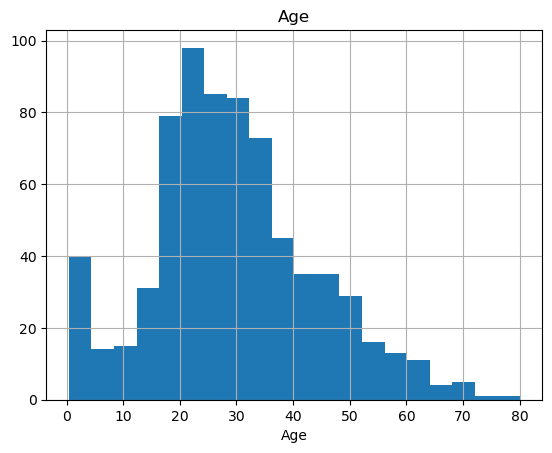

count   714.000
mean      0.000
std       1.001
min      -2.017
5%       -1.770
10%      -1.081
20%      -0.737
30%      -0.530
40%      -0.324
50%      -0.117
60%       0.145
70%       0.434
80%       0.778
90%       1.398
95%       1.812
99%       2.492
max       3.465
Name: Age_standard_scaler, dtype: float64


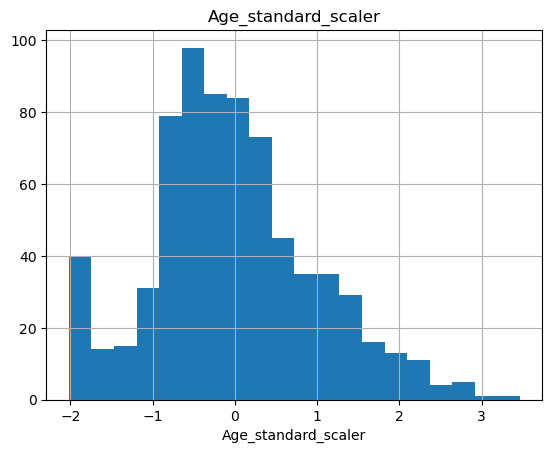

count   714.000
mean      0.095
std       0.813
min      -1.543
5%       -1.343
10%      -0.783
20%      -0.503
30%      -0.336
40%      -0.168
50%       0.000
60%       0.213
70%       0.448
80%       0.727
90%       1.231
95%       1.566
99%       2.119
max       2.909
Name: Age_robust_scaler, dtype: float64


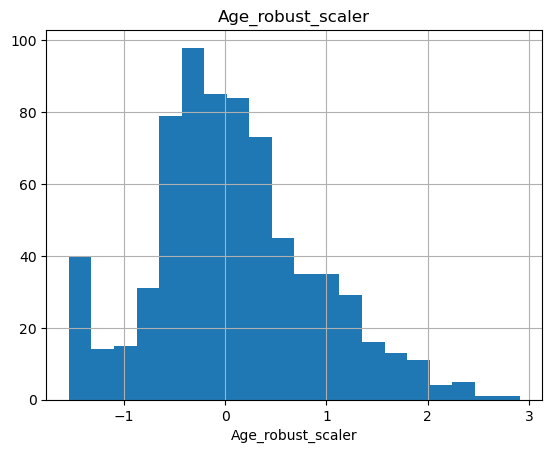

count   714.000
mean      0.368
std       0.183
min       0.000
5%        0.045
10%       0.171
20%       0.233
30%       0.271
40%       0.309
50%       0.347
60%       0.394
70%       0.447
80%       0.510
90%       0.623
95%       0.698
99%       0.822
max       1.000
Name: Age_minmax_scaler, dtype: float64


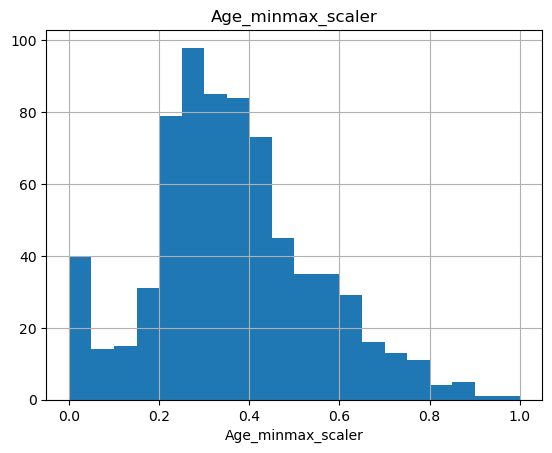

In [196]:
for col in age_cols:
    num_summary(df, col, plot=True)
    
#burada gözlemlemem gereken şey dağılımın aynı olduğu ancak ifade edilişleri farklı
#burada yappmam gereken şey değişkenlerin yapısını bozmadan ifade ediliş tarzlarını değiştirmekti
#ve ben burada değişkenin hiçbir şekilde yapısını bozmadan ifade ediliş şeklini değiştirdim. dağılımı hiçbir şeilde bozmadım,
# yaş değişkeninin taşıdığı bilgiyi bozmadım aynen duruyor. ben ifade ediliş tarzıyla ilgilenmiyorum ancak kullanacağım modller ilgileniyor.
# bu yüzden bu işlemlere dikkat etmem gerekmektedir.

In [197]:
# Numerical to Categorical: Sayısal değişkenleri kategorik değişkenlere çevirmek

# Binnig şeklinde de karşıma gelebilir.

#burada cut fonksiyonunu ya da qcut fonksiyonunu kullanabilirim.

df["Age_qcut"] = pd.qcut(df["Age"], 5) 
#yaş değişkenini qcut fonksiyonuna bölüyorum. bu metod der ki bana değişkeni ver,kaç parçaya böleceğini söylerim (5)ve labelların var mı der , eğer
# labellarımız varsa buraya labellarımı girmem gerekir. olmadığı için ben kaldırıyorum
#eğer kendi istediğim label olursa bunu oraya girebilirim.

In [198]:
df.head() # inceliyorum
#yaş değişkeni çeyrek değerlere göre bölünmüş oldu.
# eğer kullanacak olduğumuz değişkeni hangi sınıflara dönüştürebileceğimizi biliyorsak
#label argümanını kullanabiliriz.
#qcut fonksiyonu değişkeni küçükten büyüğe sıralar ve istediğim sayıda parçaya böler.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_standard_scaler,Age_robust_scaler,Age_minmax_scaler,Age_qcut
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S,-0.530,-0.336,0.271,"(19.0, 25.0]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C,0.572,0.559,0.472,"(31.8, 41.0]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S,-0.255,-0.112,0.321,"(25.0, 31.8]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S,0.365,0.392,0.435,"(31.8, 41.0]"
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S,0.365,0.392,0.435,"(31.8, 41.0]"


# 4 ) ÖZELLİK ÇIKARIMI (FEATURE EXTRACTION)

Veri bilimi için çok önemli bir konudur, ham veriden değişken, feature türetmek demektir. ikiye ayrılmaktadır, yapısal ve yapısal olmayan verilerden değişken türetmek diye ayırabiliriz. yapısal verilerden değişken türetmek derken elimizde zaten mevcut yapıda buunan değişkenler üzerinden veri türetmek demektir. diğeri ise yapısal olmayan renk gibi ses gibi görüntü gibi verilerden özellik üretmektir. kullanacağmız algoritmalar için elimizde yapısal olmayan veriler için bu verileri yapısal yani matematiksel olarak temsil edebileceğim hallere dönüştürebilmem gerekmektedir. 

örneğin elimizde aynı değişken içinde bulunan yıl saat dk gün vs gibi değişkenlerin bulunduğu verileri ayırabilirim bunun haricinde bu günlerin hangi günlere denk geldiğini tespit edip tekrardan yeni bir değişken türetebilirim bunu da değişkenlerden değişken türetmeye örnek verebilirim.

diyelimki elimizde isim değişkeni var, bu isimlerin başındabulunan ünvanları ayırabilirim bunlar bir bilgi barındırmaktadır, bu değişken normalde kardinal bilgi taşımayan bir veridir ancak bu titlelara göre kişilerin cinsiyet yaş meslek vb, bilgilerine erişebilirim, örn belki de drlar belki de titanic verisinde daha fazla hayatta kaldı diyebilirim, yani aslında özellik çıkarımı bu anlamda oldukça önemlidir, anlamlı olabilecek veriler türetilip bağımlı değişkeni etkileme oranına göre karar verebilirim ancak burada bağımlı değişkeni etkileme durumuna dikkat etmem gerekmektedir.